In [ ]:
!pip install koreanize-matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 20.3 MB/s eta 0:00:00



  Korean Election Forensics — 21st Presidential Election (2025)
    No Korean font found – attempting: apt-get install fonts-nanum ...
    Korean font installed and set to: 'NanumSquare'
  [Fallback] Using census from 22nd General Election (2024): 22nd_election_census.csv
  [Fallback] Using APT data from 22nd General Election (2024): *22nd_election_*_apt_price.csv

--- [1/5] Loading Demographic Census Data (Age-Gender cohorts) ---
    Loaded 3,894 census rows with 22 Age-Gender cohorts.

--- [2/5] Loading Apartment Transaction Data (*22nd_election_*_apt_price.csv) ---
    Calculated stable median prices for 3,427 unique Dongs.

--- [3/5] Loading Election Result Data (21st_presidential_election_result.csv, type=presidential) ---
    Presidential format detected: columns normalised.

--- [4/5] Forensics Suite ---

  [F1] Second-Digit Benford's Law (2BL) — Nationwide Naive Test
  NOTE: Uses conventional χ²(9). See [F7d] for simulation-adjusted metro result.
  N (votes >= 10)      : 3,550

/tmp/ipykernel_603/1768154219.py:1618: UserWarning: Glyph 233 (\N{LATIN SMALL LETTER E WITH ACUTE}) missing from font(s) NanumSquare.
  plt.tight_layout()
/tmp/ipykernel_603/1768154219.py:1619: UserWarning: Glyph 233 (\N{LATIN SMALL LETTER E WITH ACUTE}) missing from font(s) NanumSquare.
  plt.savefig(out_path, dpi=200, bbox_inches='tight')


Saved statistical report → 'mega_forensics_dashboard_pres21_report.png'


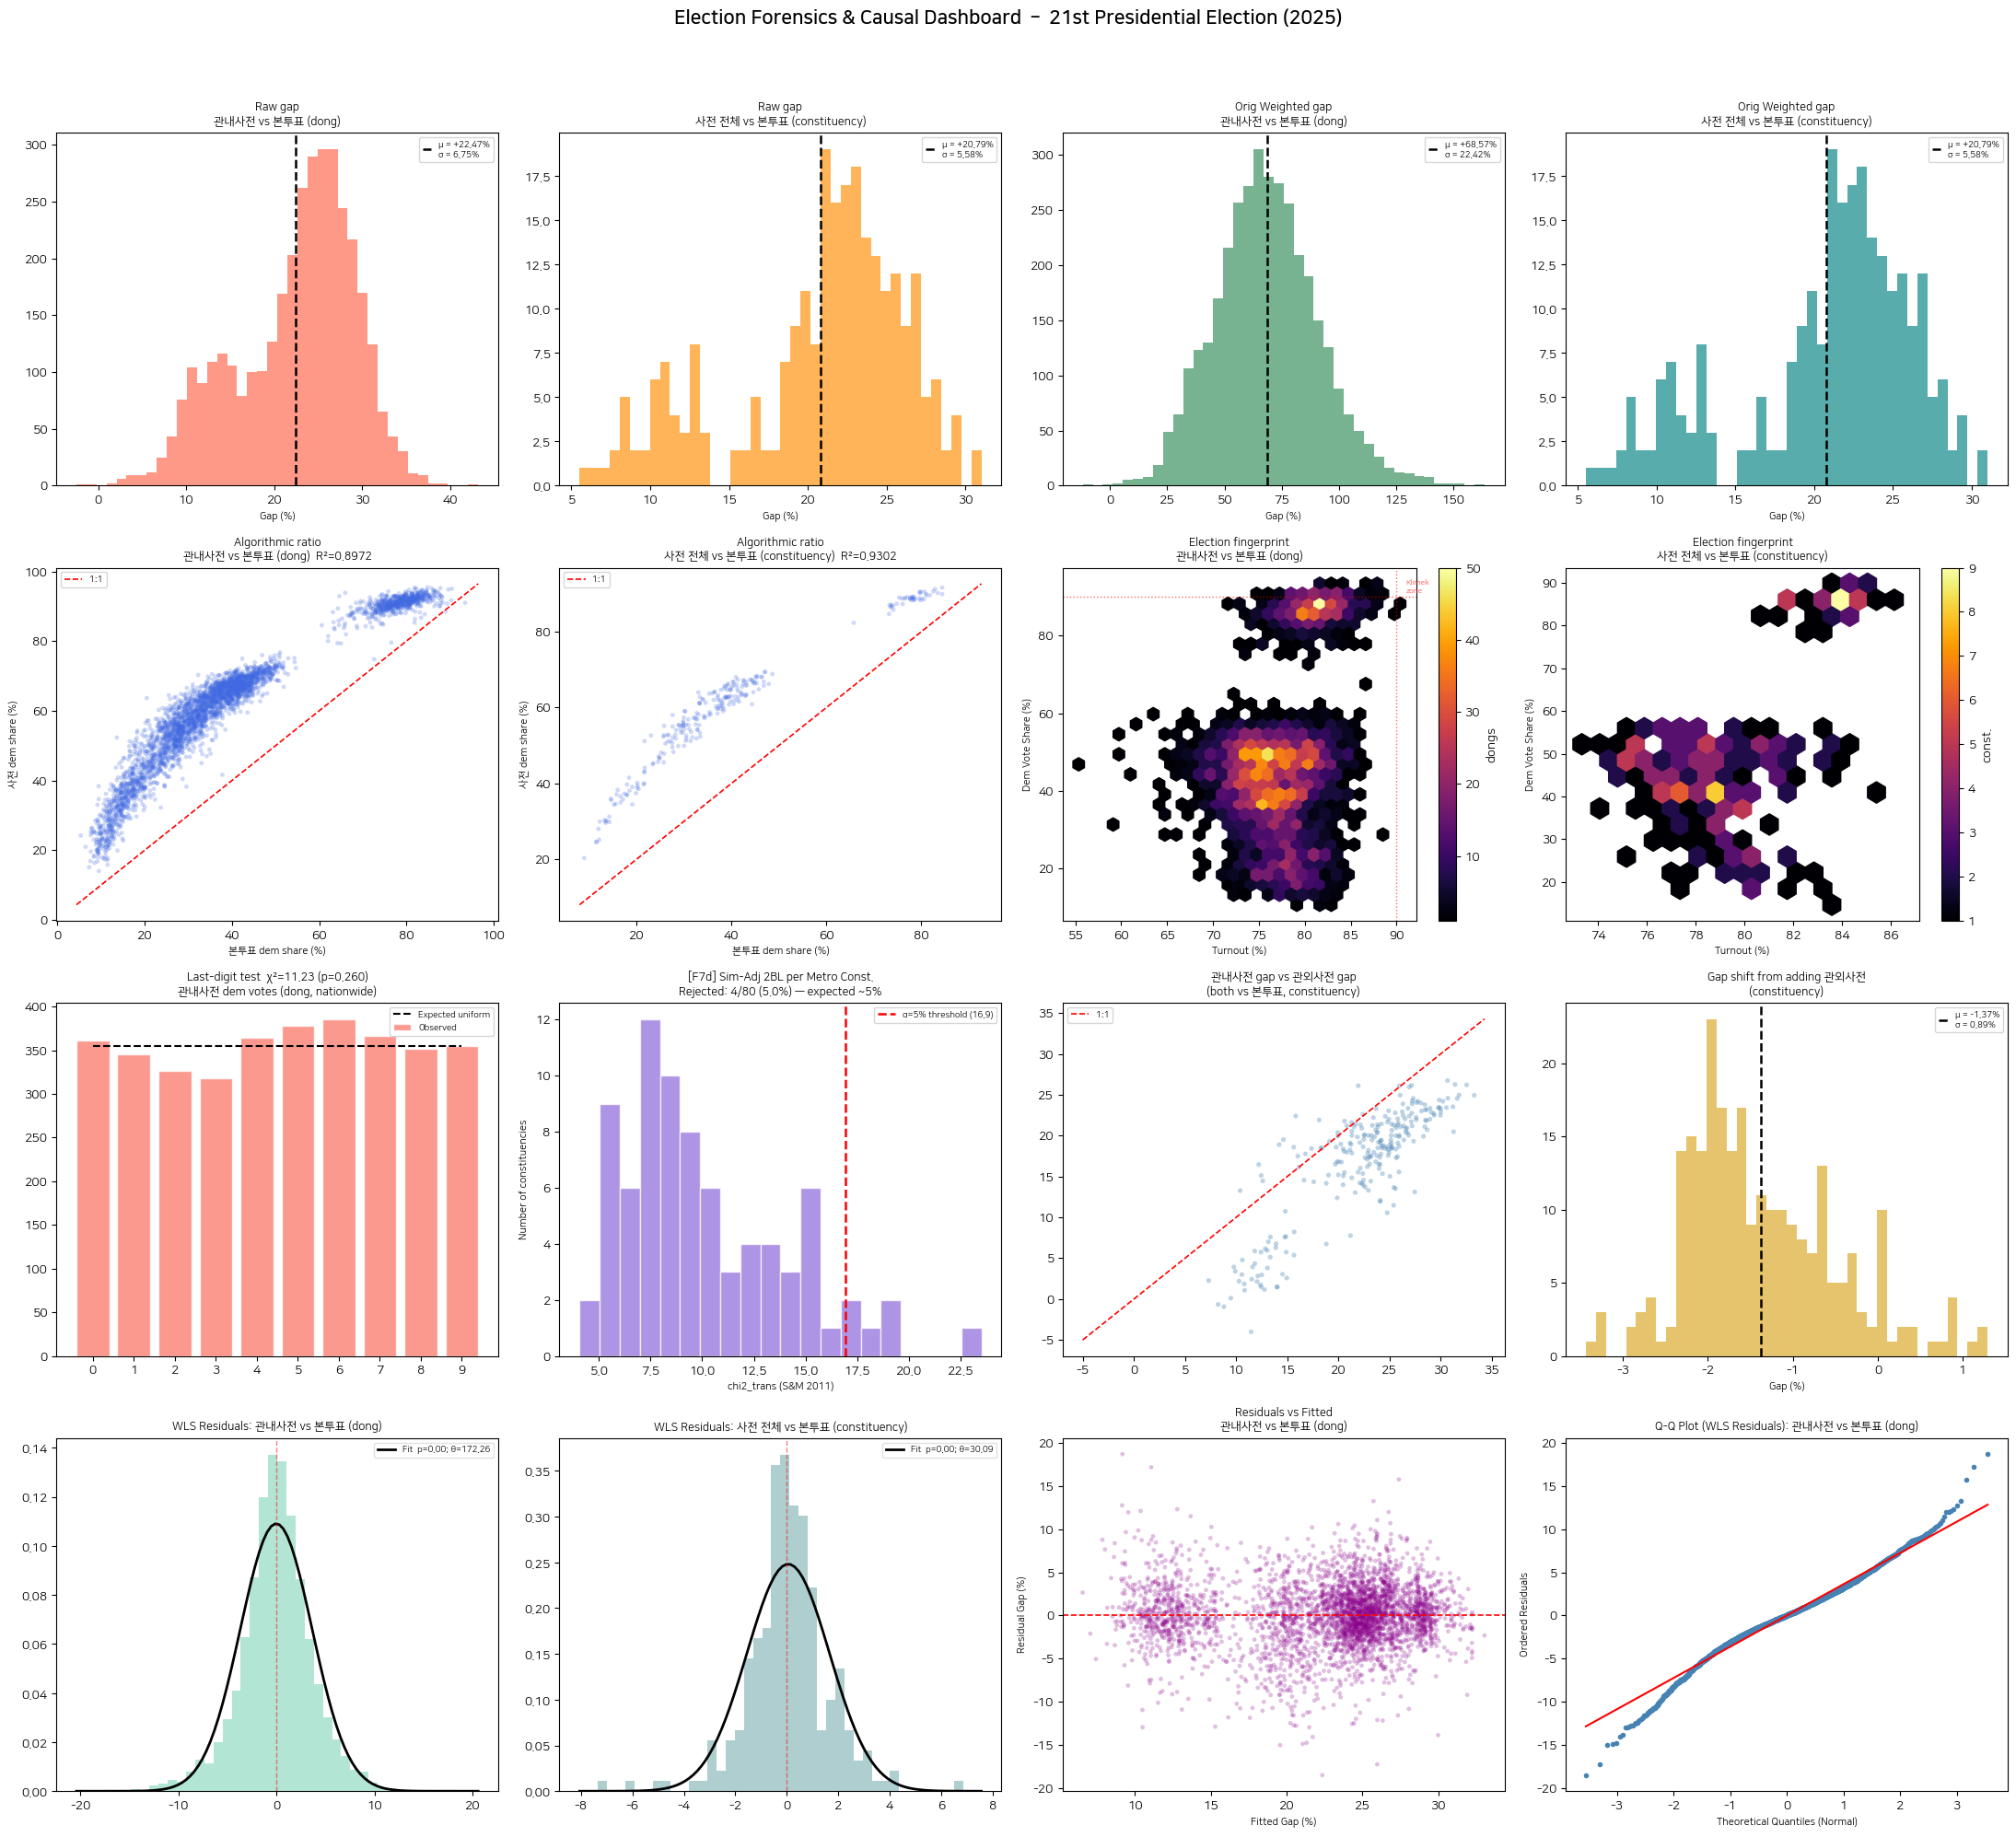

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 233 (\N{LATIN SMALL LETTER E WITH ACUTE}) missing from font(s) NanumSquare.
  fig.canvas.print_figure(bytes_io, **kw)


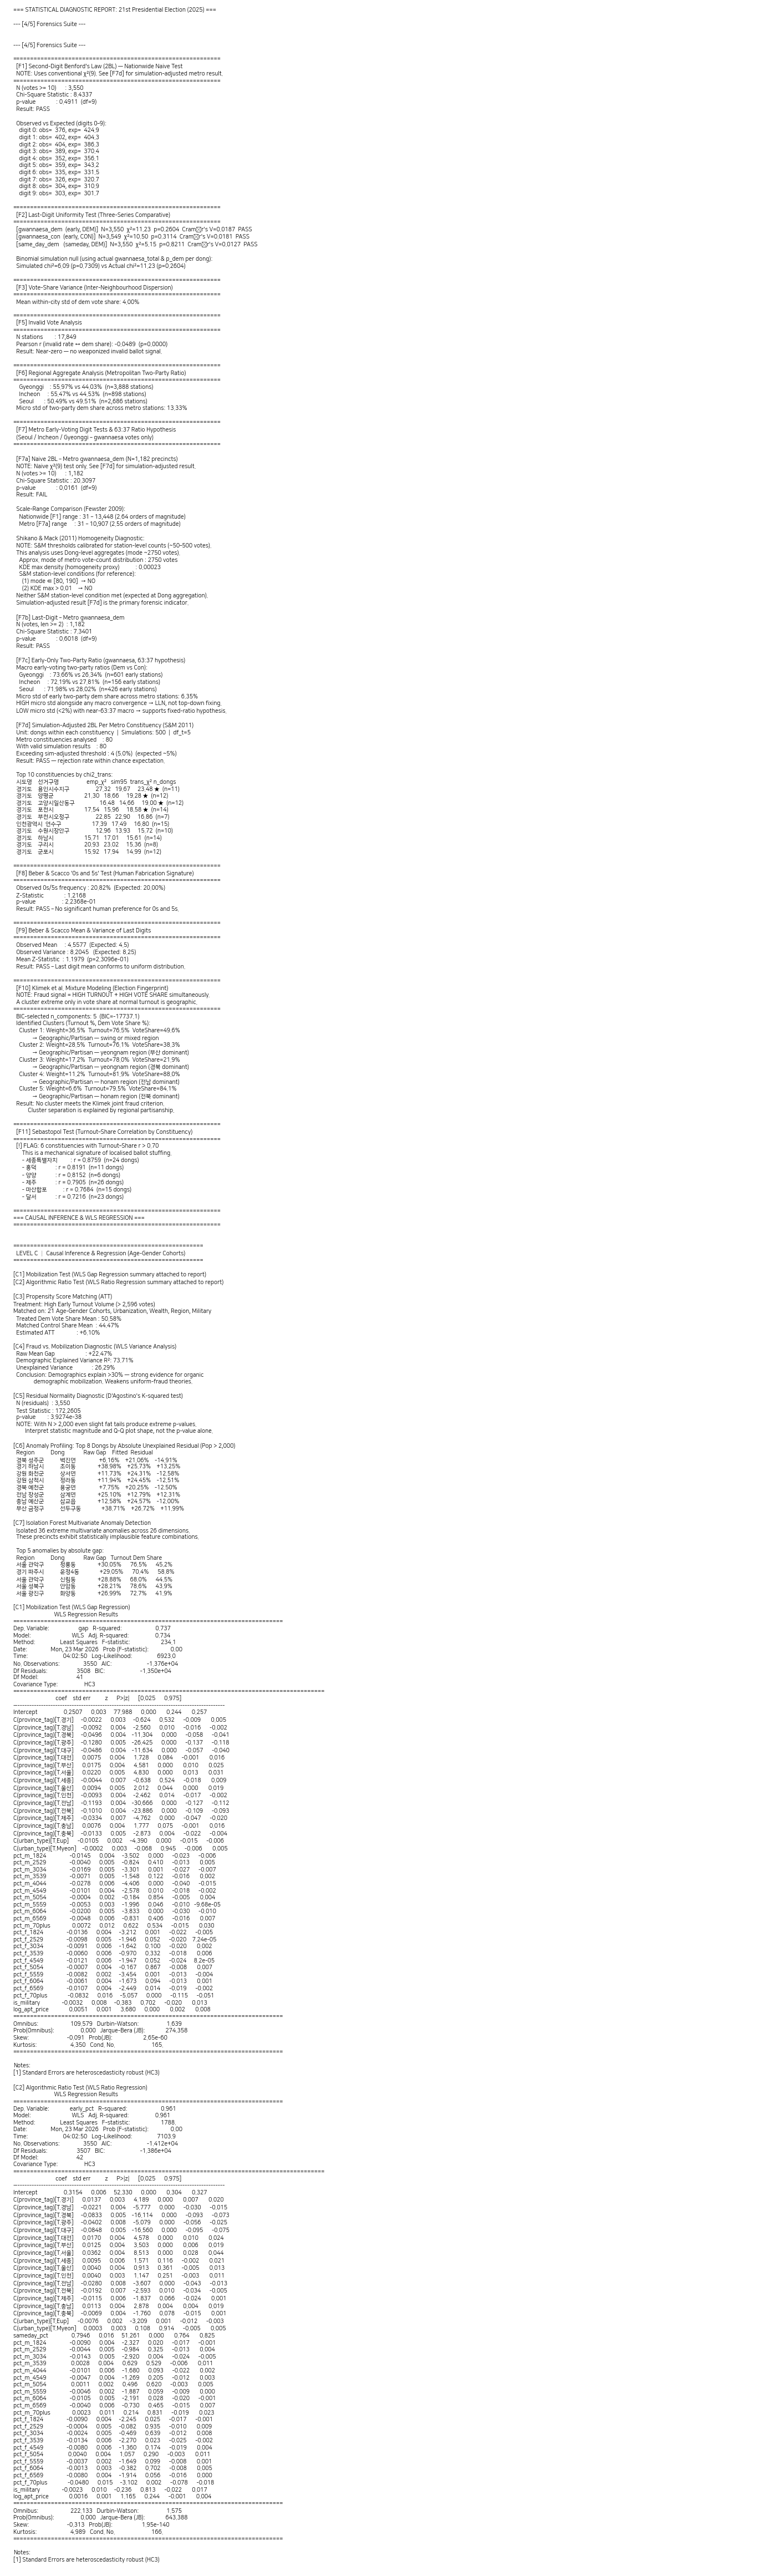

In [1]:
import pandas as pd
import numpy as np
import math
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os
import re
import glob
from difflib import get_close_matches
from scipy.stats import chisquare, pearsonr, norm, probplot, normaltest, gaussian_kde, multivariate_t
import statsmodels.formula.api as smf
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.ensemble import IsolationForest

# ==========================================
# KOREAN FONT SETUP
# ==========================================

def setup_korean_font():
    """Configure matplotlib to render Korean (Hangul) text."""
    CANDIDATES = [
        ('Noto Sans CJK', None), ('Noto Serif CJK', None),
        ('NanumSquare', None), ('NanumSquare_ac', None),
        ('NanumGothic', None), ('NanumBarunGothic', None),
        ('Malgun Gothic', None), ('Apple SD Gothic Neo', None),
        ('UnDotum', None), ('Baekmuk', None),
    ]
    all_names = {f.name for f in fm.fontManager.ttflist}
    for substr, _ in CANDIDATES:
        match = next((n for n in all_names if substr in n), None)
        if match:
            matplotlib.rcParams['font.family'] = match
            matplotlib.rcParams['axes.unicode_minus'] = False
            print(f"    Korean font set to: '{match}'")
            return

    noto_paths = [
        '/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc',
        '/usr/share/fonts/opentype/noto/NotoSerifCJK-Regular.ttc',
        '/usr/share/fonts/noto-cjk/NotoSansCJK-Regular.ttc',
    ]
    for path in noto_paths:
        if os.path.exists(path):
            fm.fontManager.addfont(path)
            prop = fm.FontProperties(fname=path)
            matplotlib.rcParams['font.family'] = prop.get_name()
            matplotlib.rcParams['axes.unicode_minus'] = False
            print(f"    Korean font loaded from: {path}")
            return

    print("    No Korean font found – attempting: apt-get install fonts-nanum ...")
    import subprocess, shutil
    if shutil.which('apt-get'):
        try:
            subprocess.run(['apt-get', 'install', '-y', '-q', 'fonts-nanum-extra'],
                           check=True, capture_output=True)
            fm.fontManager.__init__()
            all_names = {f.name for f in fm.fontManager.ttflist}
            match = next((n for n in all_names if 'NanumSquare' in n), None)
            if match:
                matplotlib.rcParams['font.family'] = match
                matplotlib.rcParams['axes.unicode_minus'] = False
                print(f"    Korean font installed and set to: '{match}'")
                return
        except Exception as e:
            print(f"    apt-get failed: {e}")

# ==========================================
# CONFIGURATION
# ==========================================
ELECTION_NUM = 'pres21'   # options: 21, 22, 'pres20', 'pres21'

ELECTION_CONFIGS = {
    21: {
        'election_type': 'general',
        'census_csv':    '21st_election_census.csv',
        'result_csv':    '21st_election_result.csv',
        'apt_csv_glob':  '*21st_election_*_apt_price.csv',
        'dem_pattern':   r'더불어민주당',
        'con_pattern':   r'미래통합당|자유한국당',
        'label':         '21st General Election (2020)',
        'dashboard_out': 'mega_forensics_dashboard_21st.png',
    },
    22: {
        'election_type': 'general',
        'census_csv':    '22nd_election_census.csv',
        'result_csv':    '22nd_election_result.csv',
        'apt_csv_glob':  '*22nd_election_*_apt_price.csv',
        'dem_pattern':   r'더불어민주당',
        'con_pattern':   r'국민의힘',
        'label':         '22nd General Election (2024)',
        'dashboard_out': 'mega_forensics_dashboard_22nd.png',
    },
    'pres20': {
        'election_type':         'presidential',
        'census_csv':            None,
        'result_csv':            '20th_presidential_election_result.csv',
        'apt_csv_glob':          None,
        'dem_pattern':           r'더불어민주당',
        'con_pattern':           r'국민의힘',
        'label':                 '20th Presidential Election (2022)',
        'dashboard_out':         'mega_forensics_dashboard_pres20.png',
        'fallback_election_num': 21,
    },
    'pres21': {
        'election_type':         'presidential',
        'census_csv':            None,
        'result_csv':            '21st_presidential_election_result.csv',
        'apt_csv_glob':          None,
        'dem_pattern':           r'더불어민주당',
        'con_pattern':           r'국민의힘',
        'label':                 '21st Presidential Election (2025)',
        'dashboard_out':         'mega_forensics_dashboard_pres21.png',
        'fallback_election_num': 22,
    },
}

CFG = ELECTION_CONFIGS[ELECTION_NUM]

SPECIAL_DONG_NAMES_GENERAL = {
    '거소·선상투표', '관외사전투표', '국외부재자투표',
    '국외부재자투표(공관)', '잘못 투입·구분된 투표지',
}
SPECIAL_DONG_NAMES_PRESIDENTIAL = {
    '거소·선상투표', '관외사전투표', '재외투표',
    '잘못 투입·구분된 투표지',
}
SPECIAL_DONG_NAMES = SPECIAL_DONG_NAMES_GENERAL

GWANNAESA_LABEL = '관내사전투표'
GWANOE_LABEL    = '관외사전투표'
META_CANDIDATES = {'선거인수', '투표수', '무효 투표수', '기권자수'}

PROV_FULL_TO_SHORT = {
    '서울특별시': '서울', '부산광역시': '부산', '대구광역시': '대구',
    '인천광역시': '인천', '광주광역시': '광주', '대전광역시': '대전',
    '울산광역시': '울산', '세종특별자치시': '세종',
    '경기도': '경기', '강원도': '강원', '강원특별자치도': '강원',
    '충청북도': '충북', '충청남도': '충남',
    '전라북도': '전북', '전북특별자치도': '전북', '전라남도': '전남',
    '경상북도': '경북', '경상남도': '경남', '제주특별자치도': '제주',
}

# Known strongly partisan regions — used in F10 to avoid mislabelling
# geographic partisanship as Klimek fraud.
# Honam (전라남/북도, 광주) overwhelmingly votes for the Democratic party.
# Yeongnam (경상남/북도, 대구, 부산, 울산) overwhelmingly votes conservative.
PARTISAN_REGION_PROVINCES = {
    'honam':   {'전남', '전북', '광주'},
    'yeongnam':{'경북', '경남', '대구', '부산', '울산'},
}

AGE_GENDER_COLS = [
    'pct_m_1824', 'pct_m_2529', 'pct_m_3034', 'pct_m_3539', 'pct_m_4044', 'pct_m_4549',
    'pct_m_5054', 'pct_m_5559', 'pct_m_6064', 'pct_m_6569', 'pct_m_70plus',
    'pct_f_1824', 'pct_f_2529', 'pct_f_3034', 'pct_f_3539', 'pct_f_4044', 'pct_f_4549',
    'pct_f_5054', 'pct_f_5559', 'pct_f_6064', 'pct_f_6569', 'pct_f_70plus'
]

# ==========================================
# SHARED NAME NORMALISATION UTILITIES
# ==========================================

def normalize_dong_name(name: str) -> str:
    if not isinstance(name, str): return ""
    name = re.sub(r'\(.*?\)', '', name).strip().replace('.', '·')
    name = re.sub(r'제(\d)', r'\1', name)
    name = re.sub(r'·\d+', '', name)
    name = re.sub(r'(\d+)(동|읍|면)$', r'\2', name)
    return re.sub(r'\s+', ' ', name)

def split_admin_tokens(name: str) -> list:
    tokens, buf = [], []
    for ch in name:
        buf.append(ch)
        if ch in '시군구' and len(buf) >= 2:
            tokens.append(''.join(buf))
            buf = []
    if buf: tokens.append(''.join(buf))
    return [t for t in tokens if t]

def normalize_sigungu(name: str) -> list:
    if not isinstance(name, str): return []
    name = re.sub(r'\(.*?\)', '', name).strip()
    if not name: return []
    tokens = split_admin_tokens(name)
    if not tokens:
        stripped = re.sub(r'[시군구갑을병정무]$', '', name).strip()
        return [stripped] if stripped else []
    si_gun_count = sum(1 for t in tokens if t[-1] in '시군' and len(t) >= 2)
    gu_count     = sum(1 for t in tokens if t[-1] == '구' and len(t) >= 2)
    ordered = tokens if (si_gun_count >= 2 or (si_gun_count == 0 and gu_count >= 2)) else list(reversed(tokens))
    candidates = []
    for t in ordered:
        key = re.sub(r'[시군구]$', '', t).strip()
        if key and key not in candidates: candidates.append(key)
    return candidates

def get_urban_type(name: str) -> str:
    if pd.isna(name): return 'Unknown'
    name = str(name).strip()
    if re.search(r'(읍)\d*$', name): return 'Eup'
    elif re.search(r'(면)\d*$', name): return 'Myeon'
    else: return 'Dong'

def check_military_zone(row):
    sgg = str(row.get('area2_name', ''))
    dong = str(row.get('name', ''))
    military_dongs = [
        '진동면', '군내면', '장단면', '파평면', '중면', '장남면', '백학면', '왕징면',
        '근북면', '근동면', '원동면', '원남면', '임남면', '동송읍', '철원읍',
        '상서면', '서화면', '방산면', '해안면', '현내면',
        '백령면', '대청면', '연평면', '신도안면', '오천읍', '고경면'
    ]
    if any(m_dong in dong for m_dong in military_dongs): return 1
    if '진해구' in sgg: return 1
    return 0

# ==========================================
# 1. DEMOGRAPHIC & ASSET DATA LOADERS
# ==========================================

def _detect_year_prefix(df: pd.DataFrame) -> str:
    for col in df.columns:
        m = re.match(r'(\d{4}년\d{2}월)_계_총인구수', col)
        if m: return m.group(1)
    raise ValueError("Cannot detect census year prefix.")

def load_census_csv(csv_path: str) -> pd.DataFrame:
    print(f"\n--- [1/5] Loading Demographic Census Data (Age-Gender cohorts) ---")
    if not csv_path:
        print("    [!] No census CSV specified — covariate columns will be NaN.")
        return pd.DataFrame()
    if not os.path.exists(csv_path): return pd.DataFrame()
    try:
        try: df = pd.read_csv(csv_path, encoding='utf-8', low_memory=False)
        except UnicodeDecodeError: df = pd.read_csv(csv_path, encoding='cp949', low_memory=False)

        prefix = _detect_year_prefix(df)
        voting_age_cols = ([f"{prefix}_계_{a}세" for a in range(18, 100)] + [f"{prefix}_계_100세 이상"])
        cols_4059 = [f"{prefix}_계_{a}세" for a in range(40, 60)]

        all_target_cols = list(voting_age_cols)
        for g in ['남', '여']:
            for a in range(18, 100):
                all_target_cols.append(f"{prefix}_{g}_{a}세")
            all_target_cols.append(f"{prefix}_{g}_100세 이상")

        for col in set(all_target_cols):
            if col in df.columns:
                df[col] = df[col].astype(str).str.replace(',', '', regex=False).pipe(pd.to_numeric, errors='coerce').fillna(0)

        df = df.copy()
        df['total_voting_pop'] = df[[c for c in voting_age_cols if c in df.columns]].sum(axis=1)
        df = df[df['total_voting_pop'] > 0].copy()

        ranges = [(18, 25, '1824'), (25, 30, '2529'), (30, 35, '3034'), (35, 40, '3539'),
                  (40, 45, '4044'), (45, 50, '4549'), (50, 55, '5054'), (55, 60, '5559'),
                  (60, 65, '6064'), (65, 70, '6569')]

        for g, g_str in [('남', 'm'), ('여', 'f')]:
            for r_start, r_end, r_str in ranges:
                cols = [f"{prefix}_{g}_{a}세" for a in range(r_start, r_end)]
                col_name = f'pct_{g_str}_{r_str}'
                df[col_name] = df[[c for c in cols if c in df.columns]].sum(axis=1) / df['total_voting_pop']

            cols_70 = [f"{prefix}_{g}_{a}세" for a in range(70, 100)] + [f"{prefix}_{g}_100세 이상"]
            col_name_70 = f'pct_{g_str}_70plus'
            df[col_name_70] = df[[c for c in cols_70 if c in df.columns]].sum(axis=1) / df['total_voting_pop']

        df['demographic_propensity'] = df[[c for c in cols_4059 if c in df.columns]].sum(axis=1) / df['total_voting_pop']

        def extract_census_keys(admin_name):
            if not isinstance(admin_name, str): return [], ""
            clean = re.sub(r'\(.*?\)', '', admin_name).strip()
            parts = clean.split()
            dong_norm = normalize_dong_name(parts[-1]) if parts else ""
            sgg_cands = []
            for token in reversed(parts[:-1]):
                for c in normalize_sigungu(token):
                    if c not in sgg_cands: sgg_cands.append(c)
            return sgg_cands, dong_norm

        rows = []
        for _, row in df.iterrows():
            sgg_cands, dong_norm = extract_census_keys(row['행정구역'])
            row_dict = {
                'sgg_candidates': sgg_cands, 'primary_sgg': sgg_cands[0] if sgg_cands else "",
                'dong_norm': dong_norm, 'dong_raw': row['행정구역'],
                'demographic_propensity': row['demographic_propensity']
            }
            for col in AGE_GENDER_COLS:
                row_dict[col] = row.get(col, np.nan)
            rows.append(row_dict)

        census = pd.DataFrame(rows)
        print(f"    Loaded {len(census):,} census rows with 22 Age-Gender cohorts.")
        return census
    except Exception as e:
        print(f"[!] Error processing census CSV: {e}")
        return pd.DataFrame()

def load_apt_csv(glob_pattern: str) -> pd.DataFrame:
    print(f"\n--- [2/5] Loading Apartment Transaction Data ({glob_pattern}) ---")
    if not glob_pattern:
        print("    [!] No APT CSV glob specified — wealth proxy will be skipped.")
        return pd.DataFrame()
    file_list = glob.glob(glob_pattern)
    if not file_list:
        print("[!] No APT CSVs found matching the pattern. Wealth proxy will be skipped.")
        return pd.DataFrame()

    df_list = []
    for file in file_list:
        try:
            try: df_temp = pd.read_csv(file, encoding='utf-8', skiprows=15)
            except UnicodeDecodeError: df_temp = pd.read_csv(file, encoding='cp949', skiprows=15)
            df_list.append(df_temp)
        except Exception as e:
            print(f"    [!] Error reading {file}: {e}")

    if not df_list:
        return pd.DataFrame()

    df = pd.concat(df_list, ignore_index=True)

    try:
        df['거래금액(만원)'] = pd.to_numeric(df['거래금액(만원)'].astype(str).str.replace(',', '').str.strip(), errors='coerce')
        df['전용면적(㎡)'] = pd.to_numeric(df['전용면적(㎡)'], errors='coerce')
        df['price_per_sqm'] = df['거래금액(만원)'] / df['전용면적(㎡)']

        def parse_loc(x):
            parts = str(x).split()
            prov = PROV_FULL_TO_SHORT.get(parts[0], parts[0]) if len(parts) > 0 else ""
            if len(parts) > 2:
                sgg_list = normalize_sigungu(parts[1])
                sgg = sgg_list[0] if sgg_list else ""
            else:
                sgg = ""
            dong = normalize_dong_name(parts[-1]) if len(parts) > 0 else ""
            return pd.Series([prov, sgg, dong])

        df[['prov', 'sgg', 'dong_norm']] = df['시군구'].apply(parse_loc)
        apt_agg = df.groupby(['prov', 'sgg', 'dong_norm'])['price_per_sqm'].median().reset_index()
        apt_agg.rename(columns={'price_per_sqm': 'median_apt_price_sqm'}, inplace=True)
        print(f"    Calculated stable median prices for {len(apt_agg):,} unique Dongs.")
        return apt_agg
    except Exception as e:
        print(f"[!] Error processing concatenated APT data: {e}")
        return pd.DataFrame()

# ==========================================
# 2. ELECTION CSV LOADER
# ==========================================

def load_election_csv(csv_path: str, dem_pattern: str, con_pattern: str,
                      election_type: str = 'general'):
    """
    Load election results into three DataFrames: dong-level, constituency-level,
    and station-level.

    Presidential vs General column differences
    ──────────────────────────────────────────
    Presidential CSV columns    → renamed to general-election internal names
      구시군명  (SGU)            → 선거구명   (constituency)
      읍면동명  (dong)           → 법정읍면동명 (legal dong name)

    Universal sum_people correction (ALL election types)
    ─────────────────────────────────────────────────────
    The NEC records 선거인수 (registered voters) split across two separate rows
    for EVERY election type — not just presidential:
      • Same-day station 선거인수  = registered voters who did NOT vote early
      • 관내사전투표 선거인수       = registered voters who voted early
                                     (removed from the same-day rolls)
    Summing only the same-day rows therefore UNDERCOUNTS total registered voters
    by ~37% on average (the early-voting participation rate), inflating calculated
    turnout well above 100% for many dongs.

    Total registered voters = same-day 선거인수 + gwannaesa 선거인수  (all elections)

    Similarly, 관외사전투표 (domestic absentee) voters have their own 선거인수
    row at the constituency level and must be added there too.
    """
    print(f"\n--- [3/5] Loading Election Result Data ({csv_path}, type={election_type}) ---")
    try:
        try: df = pd.read_csv(csv_path, encoding='utf-8-sig', low_memory=False)
        except UnicodeDecodeError: df = pd.read_csv(csv_path, encoding='cp949', low_memory=False)
    except Exception as e:
        print(f"[!] Failed to read election CSV: {e}")
        return pd.DataFrame(), pd.DataFrame(), pd.DataFrame()

    if election_type == 'presidential':
        if '구시군명' not in df.columns or '읍면동명' not in df.columns:
            print("[!] Expected presidential columns (구시군명, 읍면동명) not found.")
            return pd.DataFrame(), pd.DataFrame(), pd.DataFrame()
        df = df.rename(columns={'구시군명': '선거구명', '읍면동명': '법정읍면동명'})
        special_dong_names = SPECIAL_DONG_NAMES_PRESIDENTIAL
        print(f"    Presidential format detected: columns normalised.")
    else:
        special_dong_names = SPECIAL_DONG_NAMES_GENERAL

    df['득표수']        = pd.to_numeric(df['득표수'], errors='coerce').fillna(0).astype(int)
    df['is_dem']       = df['후보자'].str.contains(dem_pattern, case=False, na=False)
    df['is_con']       = df['후보자'].str.contains(con_pattern, case=False, na=False)
    df['is_meta']      = df['후보자'].isin(META_CANDIDATES)
    df['is_gwannaesa'] = df['투표구명'] == GWANNAESA_LABEL

    dong_key  = ['시도명', '선거구명', '법정읍면동명']
    const_key = ['시도명', '선거구명']

    def sgg_cands_from_constituency(name):
        if not isinstance(name, str): return []
        if '_' in name: return normalize_sigungu(name.split('_', 1)[1])
        return normalize_sigungu(re.sub(r'[갑을병정무]$', '', name).strip())

    df_geo   = df[~df['법정읍면동명'].isin(special_dong_names)].copy()
    df_votes = df_geo[~df_geo['is_meta']].copy()

    gn_dem = df_votes[df_votes['is_dem'] & df_votes['is_gwannaesa']].groupby(dong_key)['득표수'].sum().reset_index(name='gwannaesa_dem')
    gn_tot = df_votes[df_votes['is_gwannaesa']].groupby(dong_key)['득표수'].sum().reset_index(name='gwannaesa_total')
    gn_con = df_votes[df_votes['is_con'] & df_votes['is_gwannaesa']].groupby(dong_key)['득표수'].sum().reset_index(name='gwannaesa_con')
    sd_dem = df_votes[df_votes['is_dem'] & ~df_votes['is_gwannaesa']].groupby(dong_key)['득표수'].sum().reset_index(name='same_day_dem')
    sd_tot = df_votes[~df_votes['is_gwannaesa']].groupby(dong_key)['득표수'].sum().reset_index(name='same_day_total')

    sum_people_dong = df_geo[~df_geo['is_gwannaesa'] & (df_geo['후보자'] == '선거인수')].groupby(dong_key)['득표수'].sum().reset_index(name='sum_people')
    sum_vote_geo    = df_geo[df_geo['후보자'] == '투표수'].groupby(dong_key)['득표수'].sum().reset_index(name='sum_vote_geo')

    df_dong = gn_dem.copy()
    for frame in (gn_tot, gn_con, sd_dem, sd_tot, sum_people_dong, sum_vote_geo):
        df_dong = df_dong.merge(frame, on=dong_key, how='outer')
    df_dong = df_dong.fillna(0)

    # Universal correction: add gwannaesa 선거인수 to sum_people.
    # The NEC splits the electoral roll for ALL election types — early voters are
    # removed from same-day station rolls and tracked separately under the
    # 관내사전투표 row. Omitting this addition causes turnout > 100% in many dongs.
    gn_ppl_dong = (
        df_geo[df_geo['is_gwannaesa'] & (df_geo['후보자'] == '선거인수')]
        .groupby(dong_key)['득표수'].sum()
        .reset_index(name='_gn_ppl')
    )
    df_dong = df_dong.merge(gn_ppl_dong, on=dong_key, how='left')
    df_dong['sum_people'] = df_dong['sum_people'] + df_dong['_gn_ppl'].fillna(0)
    df_dong.drop(columns=['_gn_ppl'], inplace=True)

    df_dong['sgg_candidates'] = df_dong['선거구명'].apply(sgg_cands_from_constituency)
    df_dong['primary_sgg']    = df_dong['sgg_candidates'].apply(lambda x: x[0] if x else "")
    df_dong['dong_norm']      = df_dong['법정읍면동명'].apply(normalize_dong_name)
    df_dong['province_tag']   = df_dong['시도명'].map(PROV_FULL_TO_SHORT).fillna(df_dong['시도명'])
    df_dong['area2_name']     = df_dong['선거구명']
    df_dong['name']           = df_dong['법정읍면동명']
    df_dong['urban_type']     = df_dong['name'].apply(get_urban_type)
    df_dong['is_military']    = df_dong.apply(check_military_zone, axis=1)

    # Constituency-level aggregates
    gn_dem_c  = df_votes[df_votes['is_dem'] & df_votes['is_gwannaesa']].groupby(const_key)['득표수'].sum().reset_index(name='gwannaesa_dem')
    gn_tot_c  = df_votes[df_votes['is_gwannaesa']].groupby(const_key)['득표수'].sum().reset_index(name='gwannaesa_total')
    gn_con_c  = df_votes[df_votes['is_con'] & df_votes['is_gwannaesa']].groupby(const_key)['득표수'].sum().reset_index(name='gwannaesa_con')
    gn_turn_c = df_geo[df_geo['is_gwannaesa'] & (df_geo['후보자'] == '투표수')].groupby(const_key)['득표수'].sum().reset_index(name='gwannaesa_turnout')

    df_gw   = df[df['법정읍면동명'] == GWANOE_LABEL]
    df_gw_v = df_gw[~df_gw['is_meta']]
    go_dem_c  = df_gw_v[df_gw_v['is_dem']].groupby(const_key)['득표수'].sum().reset_index(name='gwanoe_dem')
    go_tot_c  = df_gw_v.groupby(const_key)['득표수'].sum().reset_index(name='gwanoe_total')
    go_turn_c = df_gw[df_gw['후보자'] == '투표수'].groupby(const_key)['득표수'].sum().reset_index(name='gwanoe_turnout')

    sd_dem_c  = df_votes[df_votes['is_dem'] & ~df_votes['is_gwannaesa']].groupby(const_key)['득표수'].sum().reset_index(name='same_day_dem')
    sd_tot_c  = df_votes[~df_votes['is_gwannaesa']].groupby(const_key)['득표수'].sum().reset_index(name='same_day_total')
    sd_turn_c = df_geo[~df_geo['is_gwannaesa'] & (df_geo['후보자'] == '투표수')].groupby(const_key)['득표수'].sum().reset_index(name='same_day_turnout')

    reg_c = df_dong.groupby(const_key)['sum_people'].sum().reset_index(name='sum_people')

    df_const = reg_c.copy()
    for frame in (gn_dem_c, gn_tot_c, gn_con_c, gn_turn_c, go_dem_c, go_tot_c, go_turn_c, sd_dem_c, sd_tot_c, sd_turn_c):
        df_const = df_const.merge(frame, on=const_key, how='left')
    df_const = df_const.fillna(0)

    df_const['sajeong_dem']     = df_const['gwannaesa_dem']   + df_const['gwanoe_dem']
    df_const['sajeong_total']   = df_const['gwannaesa_total'] + df_const['gwanoe_total']
    df_const['sajeong_turnout'] = df_const['gwannaesa_turnout'] + df_const['gwanoe_turnout']
    df_const['total_turnout']   = df_const['sajeong_turnout'] + df_const['same_day_turnout']

    # Universal correction: add gwanoe (domestic absentee) 선거인수 at constituency
    # level. These voters appear only in the special 관외사전투표 row and are absent
    # from every dong's same-day rolls. Applies to all election types.
    go_ppl_c = (
        df_gw[df_gw['후보자'] == '선거인수']
        .groupby(const_key)['득표수'].sum()
        .reset_index(name='_go_ppl')
    )
    df_const = df_const.merge(go_ppl_c, on=const_key, how='left')
    df_const['sum_people'] = df_const['sum_people'] + df_const['_go_ppl'].fillna(0)
    df_const.drop(columns=['_go_ppl'], inplace=True)

    df_const['sgg_candidates'] = df_const['선거구명'].apply(sgg_cands_from_constituency)
    df_const['primary_sgg']    = df_const['sgg_candidates'].apply(lambda x: x[0] if x else "")
    df_const['province_tag']   = df_const['시도명'].map(PROV_FULL_TO_SHORT).fillna(df_const['시도명'])

    sk = ['시도명', '선거구명', '법정읍면동명', '투표구명']
    st_r = df[df['후보자'] == '선거인수'].groupby(sk)['득표수'].sum().reset_index(name='sum_people')
    st_v = df[df['후보자'] == '투표수'].groupby(sk)['득표수'].sum().reset_index(name='sum_vote')
    st_i = df[df['후보자'] == '무효 투표수'].groupby(sk)['득표수'].sum().reset_index(name='sum_invalid')
    st_d = df[df['is_dem']].groupby(sk)['득표수'].sum().reset_index(name='dem_votes')
    st_c = df[df['is_con']].groupby(sk)['득표수'].sum().reset_index(name='con_votes')

    df_station = st_r.copy()
    for frame in (st_v, st_i, st_d, st_c):
        df_station = df_station.merge(frame, on=sk, how='outer')
    df_station = df_station.fillna(0)

    df_station['is_early']    = df_station['투표구명'] == GWANNAESA_LABEL
    df_station['region']      = df_station['시도명'] + ' ' + df_station['선거구명']
    df_station['invalid_rate']= df_station['sum_invalid'] / df_station['sum_vote'].replace(0, np.nan)

    return df_dong, df_const, df_station

# ==========================================
# 3. MULTI-PASS DONG↔CENSUS↔APT MATCHER
# ==========================================

def merge_dong_with_covariates(df_election: pd.DataFrame, df_census: pd.DataFrame,
                                df_apt: pd.DataFrame) -> pd.DataFrame:
    if not df_census.empty:
        census_lookup = {}
        census_by_sgg = {}
        for _, row in df_census.iterrows():
            dnorm = row['dong_norm']
            covs = {'demographic_propensity': row['demographic_propensity']}
            for c in AGE_GENDER_COLS:
                covs[c] = row.get(c, np.nan)
            for sgg in row['sgg_candidates']:
                census_lookup[(sgg, dnorm)] = covs
                census_by_sgg.setdefault(sgg, []).append(dnorm)

        results = []
        for _, row in df_election.iterrows():
            covs = None
            dk  = row['dong_norm']
            sgc = row['sgg_candidates'] if isinstance(row['sgg_candidates'], list) else [row['primary_sgg']]

            if (row['primary_sgg'], dk) in census_lookup:
                covs = census_lookup[(row['primary_sgg'], dk)]
            if covs is None and '·' in dk:
                k1b = (row['primary_sgg'], dk.replace('·', ''))
                if k1b in census_lookup: covs = census_lookup[k1b]
            if covs is None:
                for sgg in sgc[1:]:
                    if (sgg, dk) in census_lookup: covs = census_lookup[(sgg, dk)]; break
            if covs is None:
                for sgg in sgc:
                    pool = census_by_sgg.get(sgg, [])
                    if pool:
                        m = get_close_matches(dk, pool, n=1, cutoff=0.82)
                        if m and (sgg, m[0]) in census_lookup:
                            covs = census_lookup[(sgg, m[0])]; break
            if covs is None:
                covs = {k: np.nan for k in ['demographic_propensity'] + AGE_GENDER_COLS}

            rd = row.to_dict()
            rd.update(covs)
            results.append(rd)
        df_out = pd.DataFrame(results)
    else:
        df_out = df_election.copy()

    if not df_apt.empty:
        df_out = df_out.merge(df_apt,
                              left_on=['province_tag', 'primary_sgg', 'dong_norm'],
                              right_on=['prov', 'sgg', 'dong_norm'], how='left')
        sgg_med  = df_out.groupby('primary_sgg')['median_apt_price_sqm'].transform('median')
        df_out['median_apt_price_sqm'] = df_out['median_apt_price_sqm'].fillna(sgg_med)
        prov_med = df_out.groupby('province_tag')['median_apt_price_sqm'].transform('median')
        df_out['median_apt_price_sqm'] = df_out['median_apt_price_sqm'].fillna(prov_med)
        df_out['median_apt_price_sqm'] = df_out['median_apt_price_sqm'].fillna(df_out['median_apt_price_sqm'].median())
        df_out['log_apt_price'] = np.log1p(df_out['median_apt_price_sqm'])
    else:
        df_out['log_apt_price'] = 0.0

    return df_out[df_out['pct_f_4044'].notna()].copy()

def merge_const_with_covariates(df_const: pd.DataFrame,
                                 df_dong_merged: pd.DataFrame) -> pd.DataFrame:
    if df_dong_merged.empty or 'pct_f_4044' not in df_dong_merged.columns:
        return df_const.copy()

    const_key = ['시도명', '선거구명']
    dm = df_dong_merged.dropna(subset=['pct_f_4044']).copy()

    agg_funcs = {'_reg': ('sum_people', 'sum')}
    for col in AGE_GENDER_COLS:
        dm[f'_pw_{col}'] = dm[col] * dm['sum_people']
        agg_funcs[f'_pw_{col}_sum'] = (f'_pw_{col}', 'sum')

    out_cols = list(AGE_GENDER_COLS)

    if 'log_apt_price' in dm.columns:
        dm['_pw_log_apt_price'] = dm['log_apt_price'] * dm['sum_people']
        agg_funcs['_pw_log_apt_price_sum'] = ('_pw_log_apt_price', 'sum')

    agg = dm.groupby(const_key).agg(**agg_funcs).reset_index()

    for col in AGE_GENDER_COLS:
        agg[col] = agg[f'_pw_{col}_sum'] / agg['_reg'].replace(0, np.nan)

    if 'log_apt_price' in dm.columns:
        agg['log_apt_price'] = agg['_pw_log_apt_price_sum'] / agg['_reg'].replace(0, np.nan)
        out_cols.append('log_apt_price')

    return df_const.merge(agg[const_key + out_cols], on=const_key, how='left')

# ==========================================
# 4. FORENSICS ENGINE
# ==========================================

def categorize_metro(region: str) -> str:
    if not isinstance(region, str): return "Other"
    if '인천' in region or '계양' in region or '연수' in region: return "Incheon"
    if any(c in region for c in ('수원', '고양', '성남', '용인', '경기')): return "Gyeonggi"
    if '서울' in region: return "Seoul"
    return "Other"


def compute_benford_2bl(vote_series: pd.Series) -> tuple:
    """
    Second-Digit Benford's Law (2BL) test.
    P(d) = sum_{k=1}^{9} log10(1 + 1/(10k + d))
    Returns (obs, exp, chi2, p, n).
    """
    valid = vote_series[vote_series >= 10].astype(int).astype(str)
    second_digits = valid.str[1].astype(int)
    n = len(second_digits)
    obs_2bl = second_digits.value_counts().reindex(range(10), fill_value=0).sort_index()
    benford_probs = np.array(
        [sum(math.log10(1.0 + 1.0 / (10 * k + d)) for k in range(1, 10))
         for d in range(10)]
    )
    exp_2bl = benford_probs * n
    chi2_2bl, p_2bl = chisquare(obs_2bl.values, f_exp=exp_2bl)
    return obs_2bl, exp_2bl, chi2_2bl, p_2bl, n


def compute_benford_2bl_statistic(vote_series: pd.Series) -> float:
    """Compute only the 2BL chi-square statistic."""
    valid = vote_series[vote_series >= 10].astype(int).astype(str)
    if len(valid) == 0:
        return np.nan
    second_digits = valid.str[1].astype(int)
    n = len(second_digits)
    obs_2bl = second_digits.value_counts().reindex(range(10), fill_value=0).sort_index()
    benford_probs = np.array(
        [sum(math.log10(1.0 + 1.0 / (10 * k + d)) for k in range(1, 10))
         for d in range(10)]
    )
    exp_2bl = benford_probs * n
    chi2, _ = chisquare(obs_2bl.values, f_exp=exp_2bl)
    return chi2


def simulate_2bl_critical_value(
    df_constituency: pd.DataFrame,
    dem_col: str = 'gwannaesa_dem',
    con_col: str = 'gwannaesa_con',
    total_col: str = 'gwannaesa_total',
    n_simulations: int = 500,
    df_t: int = 5
) -> dict:
    """
    Shikano & Mack (2011) simulation-based 2BL critical value.

    Fits a multivariate Student-t on vote-share log-ratios (Katz & King 1999),
    draws 500 synthetic elections, derives a constituency-specific 95th-percentile
    chi-square critical value, and transforms the empirical statistic to that scale.
    chi2_trans > 16.9 indicates rejection after simulation-based correction.
    """
    df_sub = df_constituency[df_constituency[total_col] > 0].copy()
    if len(df_sub) < 5:
        return {'empirical_chi2': np.nan, 'chi2_sim95': np.nan, 'chi2_trans': np.nan}

    eps = 1e-5
    v_dem   = np.maximum(df_sub[dem_col]   / df_sub[total_col], eps)
    v_con   = np.maximum(df_sub[con_col]   / df_sub[total_col], eps)
    v_other = np.maximum(1.0 - v_dem - v_con, eps)
    denom   = v_dem + v_con + v_other
    v_dem, v_con, v_other = v_dem / denom, v_con / denom, v_other / denom

    y_dem = np.log(v_dem / v_other)
    y_con = np.log(v_con / v_other)
    Y = np.column_stack([y_dem, y_con])

    mu = np.mean(Y, axis=0)
    S  = np.cov(Y, rowvar=False)
    shape_matrix = S * (df_t - 2) / df_t if df_t > 2 else S
    shape_matrix = np.atleast_2d(shape_matrix)

    try:
        rv = multivariate_t(loc=mu, shape=shape_matrix, df=df_t)
    except Exception:
        return {'empirical_chi2': np.nan, 'chi2_sim95': np.nan, 'chi2_trans': np.nan}

    actual_voters = df_sub[total_col].values
    simulated_chi2_stats = []

    for _ in range(n_simulations):
        Y_sim = rv.rvs(size=len(df_sub))
        if len(df_sub) == 1:
            Y_sim = Y_sim.reshape(1, -1)
        exp_y_dem = np.exp(Y_sim[:, 0])
        exp_y_con = np.exp(Y_sim[:, 1])
        denom_sim = 1.0 + exp_y_dem + exp_y_con
        v_dem_sim = exp_y_dem / denom_sim
        sim_counts = np.round(v_dem_sim * actual_voters)
        sim_chi2 = compute_benford_2bl_statistic(pd.Series(sim_counts))
        if not np.isnan(sim_chi2):
            simulated_chi2_stats.append(sim_chi2)

    if not simulated_chi2_stats:
        return {'empirical_chi2': np.nan, 'chi2_sim95': np.nan, 'chi2_trans': np.nan}

    empirical_chi2 = compute_benford_2bl_statistic(df_sub[dem_col])
    chi2_sim95     = np.percentile(simulated_chi2_stats, 95)
    chi2_trans = (empirical_chi2 * 16.9 / chi2_sim95) if chi2_sim95 > 0 else np.nan

    return {
        'empirical_chi2': empirical_chi2,
        'chi2_sim95':     chi2_sim95,
        'chi2_trans':     chi2_trans,
    }


def _classify_gmm_cluster(t_center: float, v_center: float,
                           province_tag_series: pd.Series) -> str:
    """
    Classify a GMM cluster according to the Klimek et al. (2012) criterion.

    FIX (vs. prior version): The old code unconditionally labelled any
    cluster smaller than the largest one as "Anomaly/Fraud". This produced
    false positives for Korea's well-known partisan regions (Honam ~86% Dem,
    Yeongnam ~23% Dem), which are structurally separate in vote-share space
    but have entirely normal turnout and zero Klimek fraud signature.

    Genuine Klimek fraud requires BOTH:
      (1) Turnout significantly above expected (> KLIMEK_TURNOUT_THRESHOLD)
      (2) Vote share simultaneously extreme (> KLIMEK_SHARE_THRESHOLD or
          below 1 - KLIMEK_SHARE_THRESHOLD for the opposing party)
    A cluster that is extreme only on vote share, at normal turnout, is a
    geographic/partisan cluster, not a fraud cluster.

    Additionally, if the cluster provinces are dominated by a known strongly
    partisan region (Honam or Yeongnam), it is flagged as Geographic.
    """
    KLIMEK_TURNOUT_THRESHOLD = 0.90   # > 90% turnout is implausibly high
    KLIMEK_SHARE_THRESHOLD   = 0.90   # > 90% one-party share at that turnout

    # Check Klimek joint criterion
    joint_extreme = (t_center > KLIMEK_TURNOUT_THRESHOLD and
                     (v_center > KLIMEK_SHARE_THRESHOLD or v_center < (1 - KLIMEK_SHARE_THRESHOLD)))
    if joint_extreme:
        return "Klimek Anomaly — extreme turnout + vote share (fraud signal)"

    # Check known partisan geography
    if province_tag_series is not None and len(province_tag_series) > 0:
        top_prov = province_tag_series.value_counts().index[0]
        for region_name, region_provs in PARTISAN_REGION_PROVINCES.items():
            if top_prov in region_provs:
                return f"Geographic/Partisan — {region_name} region ({top_prov} dominant)"

    return "Geographic/Partisan — swing or mixed region"


def run_forensics(df_dong_raw: pd.DataFrame, df_const_raw: pd.DataFrame,
                  df_station: pd.DataFrame, df_census: pd.DataFrame,
                  df_apt: pd.DataFrame) -> dict:
    logs = []
    def log(msg):
        print(msg)
        logs.append(msg)

    log(f"\n--- [4/5] Forensics Suite ---")
    MIN_VOTES = 50

    dm = merge_dong_with_covariates(df_dong_raw, df_census, df_apt)
    dm = dm[(dm['gwannaesa_total'] > MIN_VOTES) & (dm['same_day_total'] > MIN_VOTES)].copy()
    no_cand = (dm['gwannaesa_dem'] == 0) & (dm['same_day_dem'] == 0)
    dm = dm[~no_cand].copy()

    dm['early_pct']   = dm['gwannaesa_dem'] / dm['gwannaesa_total']
    dm['sameday_pct'] = dm['same_day_dem']  / dm['same_day_total']
    dm['gap']         = dm['early_pct'] - dm['sameday_pct']
    if 'demographic_propensity' in dm.columns:
        dm['w_gap'] = dm['gap'] / dm['demographic_propensity']
    else:
        dm['w_gap'] = dm['gap']
    dm['vote_share'] = ((dm['gwannaesa_dem'] + dm['same_day_dem']) /
                        (dm['gwannaesa_total'] + dm['same_day_total']))
    dm['turnout']    = dm['sum_vote_geo'] / dm['sum_people'].replace(0, np.nan)

    # ------------------------------------------------------------------
    # [F1] SECOND-DIGIT BENFORD'S LAW (2BL) — nationwide naive test
    # ------------------------------------------------------------------
    log("\n" + "="*60)
    log("  [F1] Second-Digit Benford's Law (2BL) — Nationwide Naive Test")
    log("  NOTE: Uses conventional χ²(9). See [F7d] for simulation-adjusted metro result.")
    log("="*60)
    obs_2bl, exp_2bl, chi2_2bl, p_2bl, n_2bl = compute_benford_2bl(dm['gwannaesa_dem'])
    log(f"  N (votes >= 10)      : {n_2bl:,}")
    log(f"  Chi-Square Statistic : {chi2_2bl:.4f}")
    log(f"  p-value              : {p_2bl:.4f}  (df=9)")
    log("  Result: " + ("PASS" if p_2bl > 0.05 else "FAIL"))
    log("\n  Observed vs Expected (digits 0–9):")
    for d in range(10):
        log(f"    digit {d}: obs={obs_2bl[d]:5d}, exp={exp_2bl[d]:7.1f}")

    # ------------------------------------------------------------------
    # [F2] LAST-DIGIT UNIFORMITY TEST — three-series comparative
    #
    # Testing gwannaesa_dem alone is insufficient for forensic interpretation.
    # A failure that is symmetric (present in both parties and same-day)
    # indicates a structural counting artifact (e.g. tabulation machine
    # rounding). A failure that is asymmetric — present ONLY in one
    # candidate's early votes — is a genuine anomaly that cannot be
    # explained by counting mechanics.
    #
    # We also run a binomial simulation using the actual (gwannaesa_total,
    # p_dem) pair for each dong to establish the expected last-digit
    # distribution under pure random sampling, providing a sharper null
    # than the flat uniform assumption.
    # ------------------------------------------------------------------
    log("\n" + "="*60)
    log("  [F2] Last-Digit Uniformity Test (Three-Series Comparative)")
    log("="*60)

    def _last_digit_test(series: pd.Series, label: str) -> tuple:
        v = series.astype(int).astype(str)
        v = v[v.str.len() >= 2]
        ld = v.str[-1].astype(int)
        n  = len(ld)
        obs = ld.value_counts().reindex(range(10), fill_value=0).sort_index()
        exp = [n / 10.0] * 10
        chi2, p = chisquare(obs.values, f_exp=exp)
        cramer_v = np.sqrt(chi2 / (n * 9)) if n > 0 else np.nan
        log(f"  [{label}]  N={n:,}  χ²={chi2:.2f}  p={p:.4f}  "
            f"Cramér's V={cramer_v:.4f}  {'FAIL ★' if p < 0.05 else 'PASS'}")
        return obs, exp, chi2, p

    obs_ld, exp_ld, chi2_ld, p_ld = _last_digit_test(dm['gwannaesa_dem'],   'gwannaesa_dem  (early, DEM)')
    obs_ld_con = pd.Series(dtype=int)
    chi2_ld_con, p_ld_con = np.nan, np.nan
    if 'gwannaesa_con' in dm.columns and dm['gwannaesa_con'].sum() > 0:
        obs_ld_con, _, chi2_ld_con, p_ld_con = _last_digit_test(
            dm['gwannaesa_con'], 'gwannaesa_con  (early, CON)')
    _last_digit_test(dm['same_day_dem'], 'same_day_dem   (sameday, DEM)')

    # Asymmetry flag: early DEM fails but neither early CON nor same-day DEM fail
    ld_dem_fails = p_ld < 0.05
    ld_con_passes = np.isnan(p_ld_con) or p_ld_con >= 0.05
    if ld_dem_fails and ld_con_passes:
        log("  [!] ASYMMETRIC FAILURE: gwannaesa_dem fails while gwannaesa_con and")
        log("      same_day_dem pass. This cannot be explained by a counting machine")
        log("      artifact (which would affect all candidates equally). It is")
        log("      candidate-specific and warrants cross-election comparison.")
    elif ld_dem_fails:
        log("  NOTE: Failure appears in multiple series — likely a structural")
        log("        counting artifact rather than candidate-specific manipulation.")

    # Binomial simulation null: expected last-digit distribution given actual (N, p)
    log(f"\n  Binomial simulation null (using actual gwannaesa_total & p_dem per dong):")
    gn_tot_col = dm['gwannaesa_total'].astype(int).values
    p_dem_col  = (dm['gwannaesa_dem'] / dm['gwannaesa_total'].replace(0, np.nan)).fillna(0).values
    np.random.seed(42)
    sim_counts = np.array([np.random.binomial(int(N), float(p))
                           for N, p in zip(gn_tot_col, p_dem_col)])
    ld_sim = sim_counts % 10
    obs_sim = np.bincount(ld_sim, minlength=10)
    chi2_sim, p_sim = chisquare(obs_sim, f_exp=[len(ld_sim)/10]*10)
    log(f"  Simulated chi²={chi2_sim:.2f} (p={p_sim:.4f}) vs "
        f"Actual chi²={chi2_ld:.2f} (p={p_ld:.4f})")
    if p_ld < 0.05 and p_sim >= 0.05:
        log("  The actual deviation exceeds what pure binomial sampling predicts.")
        log("  The vote counts deviate from their own expected statistical distribution.")

    # ------------------------------------------------------------------
    # [F3] VOTE-SHARE VARIANCE
    # ------------------------------------------------------------------
    log("\n" + "="*60)
    log("  [F3] Vote-Share Variance (Inter-Neighbourhood Dispersion)")
    log("="*60)
    variances = dm.groupby('primary_sgg')['vote_share'].std().dropna() * 100
    mean_sd   = variances.mean()
    log(f"  Mean within-city std of dem vote share: {mean_sd:.2f}%")

    # ------------------------------------------------------------------
    # [F4] ALGORITHMIC RATIO CHECK (Pearson r — used for scatter plot)
    # ------------------------------------------------------------------
    corr_a, _ = pearsonr(dm['sameday_pct'], dm['early_pct'])

    # ------------------------------------------------------------------
    # [F5] INVALID VOTE ANALYSIS
    # ------------------------------------------------------------------
    log("\n" + "="*60)
    log("  [F5] Invalid Vote Analysis")
    log("="*60)
    valid_st = df_station[df_station['sum_vote'] > 0].copy()
    valid_st['dem_share'] = valid_st['dem_votes'] / valid_st['sum_vote']
    valid_inv = valid_st.dropna(subset=['invalid_rate', 'dem_share'])
    valid_inv = valid_inv[(valid_inv['invalid_rate'] < 1) & (valid_inv['dem_share'] > 0)]
    if len(valid_inv) >= 10:
        corr_inv, p_inv = pearsonr(valid_inv['invalid_rate'], valid_inv['dem_share'])
        log(f"  N stations        : {len(valid_inv):,}")
        log(f"  Pearson r (invalid rate ↔ dem share): {corr_inv:.4f}  (p={p_inv:.4f})")
        log("  Result: " + ("Near-zero — no weaponized invalid ballot signal." if abs(corr_inv) < 0.10
                             else f"Non-trivial r={corr_inv:.4f}. Warrants further investigation."))
    else:
        corr_inv, p_inv = np.nan, np.nan
        log("  [!] Insufficient data for invalid vote correlation.")

    # ------------------------------------------------------------------
    # [F6] REGIONAL AGGREGATE ANALYSIS (Metropolitan two-party ratio)
    # ------------------------------------------------------------------
    log("\n" + "="*60)
    log("  [F6] Regional Aggregate Analysis (Metropolitan Two-Party Ratio)")
    log("="*60)
    df_station['metro_zone'] = df_station['region'].apply(categorize_metro)
    valid_tp = df_station[(df_station['dem_votes'] + df_station['con_votes']) > 0].copy()
    valid_tp['two_party_dem'] = valid_tp['dem_votes'] / (valid_tp['dem_votes'] + valid_tp['con_votes'])

    metro_agg = valid_tp.groupby('metro_zone').agg(
        dem_total=('dem_votes', 'sum'),
        con_total=('con_votes', 'sum'),
        station_count=('dem_votes', 'count')
    ).reset_index()
    metro_agg['dem_ratio'] = metro_agg['dem_total'] / (metro_agg['dem_total'] + metro_agg['con_total'])
    metro_agg['con_ratio'] = 1.0 - metro_agg['dem_ratio']

    for _, row in metro_agg[metro_agg['metro_zone'] != 'Other'].iterrows():
        log(f"    {row['metro_zone']:12s}: {row['dem_ratio']*100:.2f}% vs {row['con_ratio']*100:.2f}%"
            f"  (n={row['station_count']:,} stations)")
    metro_stations = valid_tp[valid_tp['metro_zone'] != 'Other']
    metro_std = metro_stations['two_party_dem'].std() * 100
    log(f"  Micro std of two-party dem share across metro stations: {metro_std:.2f}%")

    # ------------------------------------------------------------------
    # [F7] METRO EARLY-VOTING DIGIT TESTS & 63:37 RATIO HYPOTHESIS
    # ------------------------------------------------------------------
    log("\n" + "="*60)
    log("  [F7] Metro Early-Voting Digit Tests & 63:37 Ratio Hypothesis")
    log("  (Seoul / Incheon / Gyeonggi – gwannaesa votes only)")
    log("="*60)

    METRO_PROVINCES = {'서울', '인천', '경기'}
    dm_metro = dm[dm['province_tag'].isin(METRO_PROVINCES)].copy()

    # Initialise all metro variables (populated only if sufficient data)
    obs_2bl_metro  = pd.Series(dtype=int)
    exp_2bl_metro  = np.zeros(10)
    chi2_2bl_metro = np.nan;  p_2bl_metro   = np.nan;  n_2bl_metro = 0
    obs_ld_metro   = pd.Series(dtype=int)
    exp_ld_metro   = []
    chi2_ld_metro  = np.nan;  p_ld_metro    = np.nan
    metro_early_agg  = pd.DataFrame()
    metro_early_std  = np.nan
    sm_const_results = pd.DataFrame()

    if len(dm_metro) < 10:
        log("  [!] Insufficient metro data.")
    else:
        # [F7a] Naive 2BL on metro early votes
        log(f"\n  [F7a] Naive 2BL – Metro gwannaesa_dem (N={len(dm_metro):,} precincts)")
        log(f"  NOTE: Naive χ²(9) test only. See [F7d] for simulation-adjusted result.")
        obs_2bl_metro, exp_2bl_metro, chi2_2bl_metro, p_2bl_metro, n_2bl_metro = (
            compute_benford_2bl(dm_metro['gwannaesa_dem']))
        log(f"  N (votes >= 10)      : {n_2bl_metro:,}")
        log(f"  Chi-Square Statistic : {chi2_2bl_metro:.4f}")
        log(f"  p-value              : {p_2bl_metro:.4f}  (df=9)")
        log("  Result: " + ("PASS" if p_2bl_metro > 0.05 else "FAIL"))

        # Fewster (2009) scale-range comparison
        votes_metro_sm  = dm_metro['gwannaesa_dem'][dm_metro['gwannaesa_dem'] >= 10].values.astype(float)
        votes_nation_sm = dm['gwannaesa_dem'][dm['gwannaesa_dem'] >= 10].values.astype(float)
        metro_min_sr    = int(votes_metro_sm.min())
        metro_max_sr    = int(votes_metro_sm.max())
        nation_min_sr   = int(votes_nation_sm.min())
        nation_max_sr   = int(votes_nation_sm.max())
        metro_orders    = np.log10(metro_max_sr  / metro_min_sr)  if metro_min_sr  > 0 else 0.0
        nation_orders   = np.log10(nation_max_sr / nation_min_sr) if nation_min_sr > 0 else 0.0
        log(f"\n  Scale-Range Comparison (Fewster 2009):")
        log(f"    Nationwide [F1] range : {nation_min_sr:,} – {nation_max_sr:,} ({nation_orders:.2f} orders of magnitude)")
        log(f"    Metro [F7a] range     : {metro_min_sr:,} – {metro_max_sr:,} ({metro_orders:.2f} orders of magnitude)")

        # Shikano & Mack homogeneity diagnostic
        try:
            hist_counts_sm, hist_edges_sm = np.histogram(
                votes_metro_sm, bins=min(50, max(10, len(votes_metro_sm) // 10)))
            bin_width_sm = hist_edges_sm[1] - hist_edges_sm[0]
            mode_approx  = float(hist_edges_sm[np.argmax(hist_counts_sm)] + bin_width_sm / 2.0)
            kde_obj      = gaussian_kde(votes_metro_sm)
            kde_x        = np.linspace(votes_metro_sm.min(), min(float(votes_metro_sm.max()), 2000.0), 1000)
            kde_max      = float(kde_obj(kde_x).max())
        except Exception as e:
            mode_approx, kde_max = np.nan, np.nan
            log(f"  [!] Homogeneity diagnostic error: {e}")

        log(f"\n  Shikano & Mack (2011) Homogeneity Diagnostic:")
        log(f"  NOTE: S&M thresholds calibrated for station-level counts (~50–500 votes).")
        log(f"  This analysis uses Dong-level aggregates (mode ~{mode_approx:.0f} votes).")
        log(f"    Approx. mode of metro vote-count distribution : {mode_approx:.0f} votes")
        log(f"    KDE max density (homogeneity proxy)           : {kde_max:.5f}")
        log(f"    S&M station-level conditions (for reference):")
        log(f"      (1) mode ∈ [80, 190]  → {'YES' if 80 <= mode_approx <= 190 else 'NO'}")
        log(f"      (2) KDE max > 0.01    → {'YES' if kde_max > 0.01 else 'NO'}")
        mode_in_range   = not np.isnan(mode_approx) and (80 <= mode_approx <= 190)
        kde_homogeneous = not np.isnan(kde_max) and (kde_max > 0.01)
        if mode_in_range and kde_homogeneous:
            log(f"  Both S&M station-level conditions met (unexpected at Dong level).")
        else:
            log(f"  Neither S&M station-level condition met (expected at Dong aggregation).")
            log(f"  Simulation-adjusted result [F7d] is the primary forensic indicator.")

        # [F7b] Last-digit uniformity on metro early votes
        log(f"\n  [F7b] Last-Digit – Metro gwannaesa_dem")
        v_ld_m = dm_metro['gwannaesa_dem'].astype(int).astype(str)
        v_ld_m = v_ld_m[v_ld_m.str.len() >= 2]
        obs_ld_metro  = v_ld_m.str[-1].astype(int).value_counts().reindex(range(10), fill_value=0).sort_index()
        exp_ld_metro  = [len(v_ld_m) / 10.0] * 10
        chi2_ld_metro, p_ld_metro = chisquare(obs_ld_metro.values, f_exp=exp_ld_metro)
        log(f"  N (votes, len >= 2)  : {len(v_ld_m):,}")
        log(f"  Chi-Square Statistic : {chi2_ld_metro:.4f}")
        log(f"  p-value              : {p_ld_metro:.4f}  (df=9)")
        log("  Result: " + ("PASS" if p_ld_metro > 0.05 else "FAIL"))

        # [F7c] Early-only two-party ratio per metro zone — 63:37 hypothesis
        log(f"\n  [F7c] Early-Only Two-Party Ratio (gwannaesa, 63:37 hypothesis)")
        early_st = df_station[
            df_station['is_early'] &
            (df_station['metro_zone'] != 'Other') &
            ((df_station['dem_votes'] + df_station['con_votes']) > 0)
        ].copy()
        early_st['two_party_dem_early'] = (
            early_st['dem_votes'] / (early_st['dem_votes'] + early_st['con_votes'])
        )
        metro_early_agg = early_st.groupby('metro_zone').agg(
            early_dem_total=('dem_votes', 'sum'),
            early_con_total=('con_votes', 'sum'),
            station_count=('dem_votes', 'count')
        ).reset_index()
        metro_early_agg['early_dem_ratio'] = (
            metro_early_agg['early_dem_total'] /
            (metro_early_agg['early_dem_total'] + metro_early_agg['early_con_total'])
        )
        metro_early_agg['early_con_ratio'] = 1.0 - metro_early_agg['early_dem_ratio']

        log(f"  Macro early-voting two-party ratios (Dem vs Con):")
        for _, row in metro_early_agg.iterrows():
            log(f"    {row['metro_zone']:12s}: {row['early_dem_ratio']*100:.2f}% vs {row['early_con_ratio']*100:.2f}%"
                f"  (n={row['station_count']:,} early stations)")
        metro_early_std = early_st['two_party_dem_early'].std() * 100
        log(f"  Micro std of early two-party dem share across metro stations: {metro_early_std:.2f}%")
        log(f"  HIGH micro std alongside any macro convergence → LLN, not top-down fixing.")
        log(f"  LOW micro std (<2%) with near-63:37 macro → supports fixed-ratio hypothesis.")

        # [F7d] Simulation-adjusted 2BL per metro constituency (S&M 2011)
        log(f"\n  [F7d] Simulation-Adjusted 2BL Per Metro Constituency (S&M 2011)")
        log(f"  Unit: dongs within each constituency  |  Simulations: 500  |  df_t=5")

        if 'gwannaesa_con' not in df_dong_raw.columns:
            log("  [!] gwannaesa_con not found in dong data. Skipping simulation-based test.")
        else:
            metro_dong_raw = df_dong_raw[
                df_dong_raw['province_tag'].isin(METRO_PROVINCES) &
                (df_dong_raw['gwannaesa_total'] > MIN_VOTES)
            ].copy()

            sm_rows = []
            for (sido, const_name), grp in metro_dong_raw.groupby(['시도명', '선거구명']):
                if len(grp) < 5: continue
                res = simulate_2bl_critical_value(grp, n_simulations=500, df_t=5)
                res['시도명']   = sido
                res['선거구명'] = const_name
                res['n_dongs']  = len(grp)
                sm_rows.append(res)

            if sm_rows:
                sm_const_results = pd.DataFrame(sm_rows)
                valid_mask = sm_const_results['chi2_trans'].notna()
                n_valid    = valid_mask.sum()
                n_reject   = (sm_const_results.loc[valid_mask, 'chi2_trans'] > 16.9).sum()
                pct_reject = n_reject / n_valid * 100 if n_valid > 0 else 0.0
                log(f"  Metro constituencies analysed    : {len(sm_const_results)}")
                log(f"  With valid simulation results    : {n_valid}")
                log(f"  Exceeding sim-adjusted threshold : {n_reject} ({pct_reject:.1f}%)  (expected ~5%)")
                log("  Result: " + ("PASS — rejection rate within chance expectation." if pct_reject <= 7.5
                                    else "FAIL — more rejections than chance predicts. Warrants review."))

                log(f"\n  Top 10 constituencies by chi2_trans:")
                log(f"  {'시도명':<6} {'선거구명':<20} {'emp_χ²':>8} {'sim95':>7} {'trans_χ²':>9} {'n_dongs':>7}")
                top_sm = sm_const_results.dropna(subset=['chi2_trans']).sort_values('chi2_trans', ascending=False).head(10)
                for _, r in top_sm.iterrows():
                    flag = " ★" if r['chi2_trans'] > 16.9 else ""
                    log(f"  {str(r['시도명']):<6} {str(r['선거구명']):<20} "
                        f"{r['empirical_chi2']:8.2f} {r['chi2_sim95']:7.2f} "
                        f"{r['chi2_trans']:9.2f}{flag}  (n={int(r['n_dongs'])})")
            else:
                log("  [!] No valid simulation results produced.")

    # ------------------------------------------------------------------
    # [F8] BEBER & SCACCO "0s AND 5s" TEST
    # ------------------------------------------------------------------
    log("\n" + "="*60)
    log("  [F8] Beber & Scacco '0s and 5s' Test (Human Fabrication Signature)")
    log("="*60)
    v_ld_all  = dm['gwannaesa_dem'].astype(int).astype(str)
    v_ld_all  = v_ld_all[v_ld_all.str.len() >= 2]
    last_digits = v_ld_all.str[-1].astype(int)
    count_05  = last_digits.isin([0, 5]).sum()
    n_ld      = len(last_digits)
    p_hat_05  = count_05 / n_ld if n_ld > 0 else 0.0
    p_0       = 0.20

    if n_ld > 0:
        se_p    = np.sqrt(p_0 * (1 - p_0) / n_ld)
        z_05    = (p_hat_05 - p_0) / se_p
        p_val_05 = 2 * (1 - norm.cdf(abs(z_05)))
        log(f"  Observed 0s/5s frequency : {p_hat_05*100:.2f}%  (Expected: 20.00%)")
        log(f"  Z-Statistic              : {z_05:.4f}")
        log(f"  p-value                  : {p_val_05:.4e}")
        log("  Result: " + ("PASS – No significant human preference for 0s and 5s." if p_val_05 > 0.05
                             else "FAIL – Unnatural frequency of 0s and 5s detected."))

    # ------------------------------------------------------------------
    # [F9] BEBER & SCACCO MEAN & VARIANCE OF LAST DIGITS
    # ------------------------------------------------------------------
    log("\n" + "="*60)
    log("  [F9] Beber & Scacco Mean & Variance of Last Digits")
    log("="*60)
    if n_ld > 0:
        mean_ld = last_digits.mean()
        var_ld  = last_digits.var()
        se_mean = np.sqrt(8.25 / n_ld)
        z_mean  = (mean_ld - 4.5) / se_mean
        p_val_mean = 2 * (1 - norm.cdf(abs(z_mean)))
        log(f"  Observed Mean     : {mean_ld:.4f}  (Expected: 4.5)")
        log(f"  Observed Variance : {var_ld:.4f}   (Expected: 8.25)")
        log(f"  Mean Z-Statistic  : {z_mean:.4f}  (p={p_val_mean:.4e})")
        log("  Result: " + ("PASS – Last digit mean conforms to uniform distribution." if p_val_mean > 0.05
                             else "FAIL – Last digit mean deviates from uniform expectation."))

    # ------------------------------------------------------------------
    # [F10] KLIMEK ET AL. MIXTURE MODELING (Election Fingerprint)
    #
    # FIX: Previous version used a hardcoded n_components=3 and labelled
    # any non-largest cluster as "Anomaly/Fraud". This produced false
    # positives for Korea's well-known Honam and Yeongnam partisan blocs,
    # which are structurally separate in vote-share space but have
    # completely normal turnout (~79%) and no Klimek fraud signature.
    #
    # The Klimek et al. (2012) fraud signal requires BOTH high turnout
    # (>90%) AND extreme vote share simultaneously. A cluster that is
    # extreme only on vote share at normal turnout is geographic/partisan.
    #
    # This version:
    #   (1) Selects n_components via BIC to avoid forcing exactly 3 clusters
    #   (2) Classifies each cluster with the proper Klimek joint criterion
    #   (3) Identifies dominant province per cluster to flag known partisan
    #       regions (Honam / Yeongnam) as geographic, not anomalous
    # ------------------------------------------------------------------
    log("\n" + "="*60)
    log("  [F10] Klimek et al. Mixture Modeling (Election Fingerprint)")
    log("  NOTE: Fraud signal = HIGH TURNOUT + HIGH VOTE SHARE simultaneously.")
    log("  A cluster extreme only in vote share at normal turnout is geographic.")
    log("="*60)
    fp_data_raw = dm[['turnout', 'vote_share', 'province_tag']].dropna()
    fp_data = fp_data_raw[['turnout', 'vote_share']].copy()

    if len(fp_data) > 50:
        # BIC-based n_components selection (2 to 6)
        best_gmm, best_bic, best_n = None, np.inf, 2
        for n_comp in range(2, 7):
            g = GaussianMixture(n_components=n_comp, random_state=42, n_init=3)
            g.fit(fp_data)
            bic = g.bic(fp_data)
            if bic < best_bic:
                best_bic, best_gmm, best_n = bic, g, n_comp
        gmm = best_gmm
        log(f"  BIC-selected n_components: {best_n}  (BIC={best_bic:.1f})")

        labels  = gmm.predict(fp_data)
        weights = gmm.weights_
        centers = gmm.means_
        sorted_indices = np.argsort(weights)[::-1]

        log(f"  Identified Clusters (Turnout %, Dem Vote Share %):")
        klimek_anomaly_found = False
        for i, idx in enumerate(sorted_indices):
            w         = weights[idx] * 100
            t_center  = centers[idx][0]
            v_center  = centers[idx][1]
            cluster_provs = fp_data_raw.loc[fp_data.index[labels == idx], 'province_tag']
            c_type    = _classify_gmm_cluster(t_center, v_center, cluster_provs)
            if "Anomaly" in c_type:
                klimek_anomaly_found = True
            log(f"    Cluster {i+1}: Weight={w:.1f}%  "
                f"Turnout={t_center*100:.1f}%  VoteShare={v_center*100:.1f}%")
            log(f"             → {c_type}")

        if klimek_anomaly_found:
            log("  [!] KLIMEK FLAG: At least one cluster meets the fraud criterion.")
            log("      This warrants cross-examination with F11 (Sebastopol) results.")
        else:
            log("  Result: No cluster meets the Klimek joint fraud criterion.")
            log("          Cluster separation is explained by regional partisanship.")
    else:
        log("  [!] Insufficient data for Klimek GMM modeling.")
        gmm, labels, best_n = None, None, 0

    # ------------------------------------------------------------------
    # [F11] SEBASTOPOL TEST (turnout–share correlation by constituency)
    # ------------------------------------------------------------------
    log("\n" + "="*60)
    log("  [F11] Sebastopol Test (Turnout–Share Correlation by Constituency)")
    log("="*60)
    sebastopol_flags = []
    for const, grp in dm.groupby('primary_sgg'):
        grp_clean = grp[['turnout', 'vote_share']].dropna()
        if len(grp_clean) > 5:
            r_val, p_val = pearsonr(grp_clean['turnout'], grp_clean['vote_share'])
            if r_val > 0.70 and p_val < 0.05:
                sebastopol_flags.append((const, r_val, len(grp_clean)))

    if sebastopol_flags:
        log(f"  [!] FLAG: {len(sebastopol_flags)} constituencies with Turnout–Share r > 0.70")
        log(f"      This is a mechanical signature of localised ballot stuffing.")
        for const, r_val, n_d in sorted(sebastopol_flags, key=lambda x: x[1], reverse=True):
            log(f"      - {const:<15}: r = {r_val:.4f}  (n={n_d} dongs)")
    else:
        log("  Result: PASS – No constituencies exhibited extreme Sebastopol correlations.")

    # ------------------------------------------------------------------
    # Constituency-level derived frame
    # ------------------------------------------------------------------
    cm = merge_const_with_covariates(df_const_raw, dm)
    cm = cm[(cm['sajeong_total'] > MIN_VOTES) & (cm['same_day_total'] > MIN_VOTES)].copy()
    no_cand_c = (cm['sajeong_dem'] == 0) & (cm['same_day_dem'] == 0)
    cm = cm[~no_cand_c].copy()

    cm['early_pct']     = cm['sajeong_dem']  / cm['sajeong_total']
    cm['sameday_pct']   = cm['same_day_dem'] / cm['same_day_total']
    cm['gap']           = cm['early_pct'] - cm['sameday_pct']
    if 'demographic_propensity' in cm.columns:
        cm['w_gap'] = cm['gap'] / cm['demographic_propensity']
    else:
        cm['w_gap'] = cm['gap']
    cm['gwannaesa_pct'] = cm['gwannaesa_dem'] / cm['gwannaesa_total'].replace(0, np.nan)
    cm['gwanoe_pct']    = cm['gwanoe_dem']    / cm['gwanoe_total'].replace(0, np.nan)
    cm['gwannaesa_gap'] = cm['gwannaesa_pct'] - cm['sameday_pct']
    cm['gwanoe_gap']    = cm['gwanoe_pct']    - cm['sameday_pct']
    cm['gap_shift']     = cm['gap'] - cm['gwannaesa_gap']
    cm['vote_share']    = ((cm['sajeong_dem'] + cm['same_day_dem']) /
                           (cm['sajeong_total'] + cm['same_day_total']))
    cm['turnout']       = cm['total_turnout'] / cm['sum_people'].replace(0, np.nan)

    corr_b, _ = pearsonr(cm['sameday_pct'], cm['early_pct'])

    return {
        'dong': {
            'df': dm,
            'obs_2bl': obs_2bl, 'exp_2bl': exp_2bl, 'chi2_2bl': chi2_2bl, 'p_2bl': p_2bl, 'n_2bl': n_2bl,
            'obs_ld':  obs_ld,  'exp_ld':  exp_ld,  'chi2_ld':  chi2_ld,  'p_ld':  p_ld,
            'variances': variances, 'mean_sd': mean_sd,
            'corr_inv': corr_inv, 'p_inv': p_inv,
            'metro_agg': metro_agg, 'metro_std': metro_std,
            'obs_2bl_metro': obs_2bl_metro, 'exp_2bl_metro': exp_2bl_metro,
            'chi2_2bl_metro': chi2_2bl_metro, 'p_2bl_metro': p_2bl_metro, 'n_2bl_metro': n_2bl_metro,
            'obs_ld_metro': obs_ld_metro, 'exp_ld_metro': exp_ld_metro,
            'chi2_ld_metro': chi2_ld_metro, 'p_ld_metro': p_ld_metro,
            'metro_early_agg': metro_early_agg, 'metro_early_std': metro_early_std,
            'sm_const_results': sm_const_results,
            'r2': corr_a**2,
        },
        'const': {'df': cm, 'r2': corr_b**2},
        'forensics_logs': logs,
    }

# ==========================================
# 5. CAUSAL INFERENCE & REGRESSION
# ==========================================

def run_causal_analysis(dm: pd.DataFrame, cm: pd.DataFrame):
    logs = []
    def log(msg):
        print(msg)
        logs.append(msg)

    log("\n" + "="*55)
    log("  LEVEL C │ Causal Inference & Regression (Age-Gender Cohorts)")
    log("="*55)

    model_age_gender_cols = [c for c in AGE_GENDER_COLS if c != 'pct_f_4044']
    req_cols = (['gap', 'province_tag', 'urban_type', 'is_military', 'sum_people', 'log_apt_price']
                + AGE_GENDER_COLS)
    df_mod = dm.dropna(subset=req_cols).copy()

    scaler    = StandardScaler()
    cont_cols = model_age_gender_cols + ['log_apt_price']
    df_mod[cont_cols] = scaler.fit_transform(df_mod[cont_cols])

    age_gender_formula_str = " + ".join(model_age_gender_cols)
    formula_gap = (f'gap ~ {age_gender_formula_str} + is_military + log_apt_price'
                   f' + C(province_tag) + C(urban_type)')
    model_gap = smf.wls(formula_gap, data=df_mod, weights=df_mod['sum_people']).fit(cov_type='HC3')
    log("\n[C1] Mobilization Test (WLS Gap Regression summary attached to report)")

    formula_ratio = (f'early_pct ~ sameday_pct + {age_gender_formula_str} + is_military'
                     f' + log_apt_price + C(province_tag) + C(urban_type)')
    model_ratio = smf.wls(formula_ratio, data=df_mod, weights=df_mod['sum_people']).fit(cov_type='HC3')
    log("[C2] Algorithmic Ratio Test (WLS Ratio Regression summary attached to report)")

    df_mod['residual_gap'] = model_gap.resid
    df_mod['fitted_gap']   = model_gap.fittedvalues

    # Constituency-level model
    req_cols_c = ['gap', 'province_tag', 'sum_people', 'log_apt_price'] + AGE_GENDER_COLS
    cm_mod = cm.dropna(subset=req_cols_c).copy()
    if not cm_mod.empty:
        cm_mod[cont_cols] = scaler.fit_transform(cm_mod[cont_cols])
        formula_gap_c = f'gap ~ {age_gender_formula_str} + log_apt_price + C(province_tag)'
        model_gap_c   = smf.wls(formula_gap_c, data=cm_mod, weights=cm_mod['sum_people']).fit(cov_type='HC3')
        cm_mod['residual_gap'] = model_gap_c.resid

    # Propensity score matching
    median_turnout = df_mod['gwannaesa_total'].median()
    df_mod['D_high_early'] = (df_mod['gwannaesa_total'] > median_turnout).astype(int)

    urban_dummies = pd.get_dummies(df_mod['urban_type'],     drop_first=True)
    prov_dummies  = pd.get_dummies(df_mod['province_tag'],   drop_first=True)
    X = pd.concat([df_mod[model_age_gender_cols + ['is_military', 'log_apt_price']],
                   urban_dummies, prov_dummies], axis=1)
    y = df_mod['D_high_early']

    lr = LogisticRegression(solver='liblinear', max_iter=1000)
    lr.fit(X, y)
    df_mod['propensity_score'] = lr.predict_proba(X)[:, 1]

    treated = df_mod[df_mod['D_high_early'] == 1]
    control = df_mod[df_mod['D_high_early'] == 0]
    nn = NearestNeighbors(n_neighbors=1)
    nn.fit(control[['propensity_score']])
    _, indices = nn.kneighbors(treated[['propensity_score']])
    matched_control = control.iloc[indices.flatten()]

    treated_mean       = treated['vote_share'].mean()
    matched_ctrl_mean  = matched_control['vote_share'].mean()
    att = treated_mean - matched_ctrl_mean

    log("\n[C3] Propensity Score Matching (ATT)")
    log(f"Treatment: High Early Turnout Volume (> {median_turnout:,.0f} votes)")
    log(f"Matched on: 21 Age-Gender Cohorts, Urbanization, Wealth, Region, Military")
    log(f"  Treated Dem Vote Share Mean : {treated_mean*100:.2f}%")
    log(f"  Matched Control Share Mean  : {matched_ctrl_mean*100:.2f}%")
    log(f"  Estimated ATT               : {att*100:+.2f}%")

    raw_mean  = df_mod['gap'].mean()
    r_squared = model_gap.rsquared
    log("\n[C4] Fraud vs. Mobilization Diagnostic (WLS Variance Analysis)")
    log(f"  Raw Mean Gap                     : {raw_mean*100:+.2f}%")
    log(f"  Demographic Explained Variance R²: {r_squared*100:.2f}%")
    log(f"  Unexplained Variance             : {(1-r_squared)*100:.2f}%")
    if r_squared < 0.10:
        log("  Conclusion: Demographics explain <10% of the gap — consistent with")
        log("              a uniform demographic-blind shift or unobserved covariates.")
    elif r_squared >= 0.30:
        log("  Conclusion: Demographics explain >30% — strong evidence for organic")
        log("              demographic mobilization. Weakens uniform-fraud theories.")

    res_data = df_mod['residual_gap'].replace([np.inf, -np.inf], np.nan).dropna()
    stat, p_norm = normaltest(res_data)
    log("\n[C5] Residual Normality Diagnostic (D'Agostino's K-squared test)")
    log(f"  N (residuals)  : {len(res_data):,}")
    log(f"  Test Statistic : {stat:.4f}")
    log(f"  p-value        : {p_norm:.4e}")
    log("  NOTE: With N > 2,000 even slight fat tails produce extreme p-values.")
    log("        Interpret statistic magnitude and Q-Q plot shape, not the p-value alone.")

    log("\n[C6] Anomaly Profiling: Top 8 Dongs by Absolute Unexplained Residual (Pop > 2,000)")
    log(f"  {'Region':<16} {'Dong':<14} {'Raw Gap':>9} {'Fitted':>9} {'Residual':>9}")
    valid_dongs  = df_mod[df_mod['sum_people'] >= 2000]
    top_outliers = valid_dongs.reindex(
        valid_dongs['residual_gap'].abs().sort_values(ascending=False).index).head(8)
    for _, row in top_outliers.iterrows():
        region = f"{row['province_tag']} {row['area2_name']}"[:15]
        dong   = str(row['name'])[:13]
        log(f"  {region:<16} {dong:<14} {row['gap']*100:+9.2f}% "
            f"{row['fitted_gap']*100:+9.2f}% {row['residual_gap']*100:+9.2f}%")

    # [C7] ISOLATION FOREST MULTIVARIATE ANOMALY DETECTION
    log("\n[C7] Isolation Forest Multivariate Anomaly Detection")
    iso_features = cont_cols + ['is_military', 'gap', 'turnout', 'vote_share']
    df_iso = df_mod.dropna(subset=iso_features).copy()

    if len(df_iso) > 100:
        iso = IsolationForest(contamination=0.01, random_state=42, n_estimators=200)
        df_iso['anomaly_score'] = iso.fit_predict(df_iso[iso_features])
        anomalies = df_iso[df_iso['anomaly_score'] == -1]
        log(f"  Isolated {len(anomalies)} extreme multivariate anomalies across {len(iso_features)} dimensions.")
        log(f"  These precincts exhibit statistically implausible feature combinations.")
        log(f"\n  Top 5 anomalies by absolute gap:")
        log(f"  {'Region':<16} {'Dong':<14} {'Raw Gap':>9} {'Turnout':>9} {'Dem Share':>9}")
        top_iso = anomalies.reindex(
            anomalies['gap'].abs().sort_values(ascending=False).index).head(5)
        for _, row in top_iso.iterrows():
            region = f"{row['province_tag']} {row['area2_name']}"[:15]
            dong   = str(row['name'])[:13]
            log(f"  {region:<16} {dong:<14} {row['gap']*100:+9.2f}% "
                f"{row['turnout']*100:9.1f}% {row['vote_share']*100:9.1f}%")
    else:
        log("  [!] Insufficient clean data for multivariate Isolation Forest.")

    return df_mod, cm_mod if not cm_mod.empty else cm, model_gap, model_ratio, logs

# ==========================================
# 6. DASHBOARDS & REPORTS
# ==========================================

def plot_dashboard(results: dict, out_path: str, title: str):
    print(f"\nGenerating visual dashboard → {out_path}")
    dm       = results['dong']['df']
    cm       = results['const']['df']
    obs_ld   = results['dong']['obs_ld']
    exp_ld   = results['dong']['exp_ld']
    obs_2bl  = results['dong']['obs_2bl']
    exp_2bl  = results['dong']['exp_2bl']
    r2_dong  = results['dong']['r2']
    r2_const = results['const']['r2']
    sm_const_results = results['dong'].get('sm_const_results', pd.DataFrame())

    fig, axes = plt.subplots(4, 4, figsize=(22, 20))
    fig.suptitle(f"Election Forensics & Causal Dashboard  –  {title}",
                 fontsize=15, fontweight='bold', y=0.995)

    LEVEL_A = '관내사전 vs 본투표 (dong)'
    LEVEL_B = '사전 전체 vs 본투표 (constituency)'

    def hist_gap(ax, data, label, color):
        data = data.replace([np.inf, -np.inf], np.nan).dropna()
        if len(data) == 0: return
        ax.hist(data * 100, bins=40, color=color, alpha=0.65, edgecolor='none')
        ax.axvline(data.mean() * 100, color='black', lw=1.8, ls='--',
                   label=f'μ = {data.mean()*100:+.2f}%\nσ = {data.std()*100:.2f}%')
        ax.set_title(label, fontsize=9)
        ax.set_xlabel('Gap (%)', fontsize=8)
        ax.legend(fontsize=7, handlelength=1)

    def scatter_ratio(ax, x, y, r2, label):
        if len(x) == 0 or len(y) == 0: return
        mn = min(x.min(), y.min()) * 100 - 1
        mx = max(x.max(), y.max()) * 100 + 1
        ax.scatter(x * 100, y * 100, alpha=0.25, s=12, color='royalblue', edgecolors='none')
        ax.plot([mn, mx], [mn, mx], 'r--', lw=1.2, label='1:1')
        ax.set_title(f'{label}  R²={r2:.4f}', fontsize=9)
        ax.set_xlabel('본투표 dem share (%)', fontsize=8)
        ax.set_ylabel('사전 dem share (%)', fontsize=8)
        ax.legend(fontsize=7)

    def plot_residual_hist(ax, data, label, color):
        data = data.replace([np.inf, -np.inf], np.nan).dropna() * 100
        if len(data) == 0:
            ax.axis('off'); return
        ax.hist(data, bins=40, density=True, color=color, alpha=0.5)
        mu, std = data.mean(), data.std()
        x = np.linspace(*ax.get_xlim(), 100)
        ax.plot(x, norm.pdf(x, mu, std), 'k', linewidth=2)
        ax.axvline(0, color='red', lw=1, ls='--', alpha=0.5)
        theta, p_val = normaltest(data)
        ax.set_title(f'WLS Residuals: {label}', fontsize=9)
        ax.legend([f'Fit  p={p_val:.2f}; θ={theta:.2f}'], fontsize=7,
                  loc='upper right', framealpha=0.6)

    def plot_resid_vs_fitted(ax, df_mod, label):
        if 'fitted_gap' not in df_mod.columns or 'residual_gap' not in df_mod.columns:
            ax.axis('off'); return
        x, y = df_mod['fitted_gap'] * 100, df_mod['residual_gap'] * 100
        if len(x) == 0: return
        ax.scatter(x, y, alpha=0.25, s=12, color='darkmagenta', edgecolors='none')
        ax.axhline(0, color='red', lw=1.2, ls='--')
        ax.set_title(f'Residuals vs Fitted\n{label}', fontsize=9)
        ax.set_xlabel('Fitted Gap (%)', fontsize=8)
        ax.set_ylabel('Residual Gap (%)', fontsize=8)

    def plot_qq(ax, data, title_str):
        data = data.replace([np.inf, -np.inf], np.nan).dropna() * 100
        if len(data) == 0:
            ax.axis('off'); return
        probplot(data, dist="norm", plot=ax)
        ax.set_title(f'Q-Q Plot (WLS Residuals): {title_str}', fontsize=9)
        ax.get_lines()[0].set_markerfacecolor('steelblue')
        ax.get_lines()[0].set_markeredgecolor('none')
        ax.get_lines()[0].set_markersize(4)
        ax.get_lines()[1].set_color('red')
        ax.set_xlabel('Theoretical Quantiles (Normal)', fontsize=8)
        ax.set_ylabel('Ordered Residuals', fontsize=8)

    # Row 0: gap histograms
    hist_gap(axes[0, 0], dm['gap'],                    f'Raw gap\n{LEVEL_A}',              'tomato')
    hist_gap(axes[0, 1], cm['gap'],                    f'Raw gap\n{LEVEL_B}',              'darkorange')
    hist_gap(axes[0, 2], dm.get('w_gap', dm['gap']),   f'Orig Weighted gap\n{LEVEL_A}',    'seagreen')
    hist_gap(axes[0, 3], cm.get('w_gap', cm['gap']),   f'Orig Weighted gap\n{LEVEL_B}',    'teal')

    # Row 1: scatter ratios + fingerprints
    scatter_ratio(axes[1, 0], dm['sameday_pct'], dm['early_pct'], r2_dong,  f'Algorithmic ratio\n{LEVEL_A}')
    scatter_ratio(axes[1, 1], cm['sameday_pct'], cm['early_pct'], r2_const, f'Algorithmic ratio\n{LEVEL_B}')

    fp = dm[(dm['turnout'] > 0) & (dm['turnout'] <= 1.0)]
    hb = axes[1, 2].hexbin(fp['turnout']*100, fp['vote_share']*100,
                            gridsize=28, cmap='inferno', mincnt=1)
    fig.colorbar(hb, ax=axes[1, 2], label='dongs')
    axes[1, 2].set_title(f'Election fingerprint\n{LEVEL_A}', fontsize=9)
    axes[1, 2].set_xlabel('Turnout (%)', fontsize=8)
    axes[1, 2].set_ylabel('Dem Vote Share (%)', fontsize=8)
    # Annotate Klimek fraud zone
    axes[1, 2].axvline(90, color='red', lw=1, ls=':', alpha=0.6)
    axes[1, 2].axhline(90, color='red', lw=1, ls=':', alpha=0.6)
    axes[1, 2].text(91, 91, 'Klimek\nzone', fontsize=6, color='red', alpha=0.7)

    fpc = cm[(cm['turnout'] > 0) & (cm['turnout'] <= 1.0)]
    hb2 = axes[1, 3].hexbin(fpc['turnout']*100, fpc['vote_share']*100,
                             gridsize=18, cmap='inferno', mincnt=1)
    fig.colorbar(hb2, ax=axes[1, 3], label='const.')
    axes[1, 3].set_title(f'Election fingerprint\n{LEVEL_B}', fontsize=9)
    axes[1, 3].set_xlabel('Turnout (%)', fontsize=8)
    axes[1, 3].set_ylabel('Dem Vote Share (%)', fontsize=8)

    # Row 2: digit tests, S&M per-constituency, gap scatter, gap shift
    axes[2, 0].bar(range(10), obs_ld,  color='salmon',   alpha=0.8, edgecolor='white', label='Observed')
    axes[2, 0].plot(range(10), exp_ld, 'k--', lw=1.5, label='Expected uniform')
    chi2_ld = results['dong']['chi2_ld'];  p_ld = results['dong']['p_ld']
    axes[2, 0].set_title(f'Last-digit test  χ²={chi2_ld:.2f} (p={p_ld:.3f})\n관내사전 dem votes (dong, nationwide)', fontsize=9)
    axes[2, 0].set_xticks(range(10))
    axes[2, 0].legend(fontsize=7)

    # [2,1] Sim-adjusted 2BL distribution (F7d) when available, else naive 2BL bars
    ax21 = axes[2, 1]
    if not sm_const_results.empty and 'chi2_trans' in sm_const_results.columns:
        trans_vals = sm_const_results['chi2_trans'].dropna()
        if len(trans_vals) > 0:
            ax21.hist(trans_vals, bins=20, color='mediumpurple', alpha=0.75, edgecolor='white')
            ax21.axvline(16.9, color='red', lw=1.8, ls='--', label='α=5% threshold (16.9)')
            n_reject = (trans_vals > 16.9).sum()
            pct_rej  = n_reject / len(trans_vals) * 100
            ax21.set_title(f'[F7d] Sim-Adj 2BL per Metro Const.\n'
                           f'Rejected: {n_reject}/{len(trans_vals)} ({pct_rej:.1f}%) — expected ~5%',
                           fontsize=9)
            ax21.set_xlabel('chi2_trans (S&M 2011)', fontsize=8)
            ax21.set_ylabel('Number of constituencies', fontsize=8)
            ax21.legend(fontsize=7)
        else:
            _draw_naive_2bl(ax21, obs_2bl, exp_2bl, results)
    else:
        _draw_naive_2bl(ax21, obs_2bl, exp_2bl, results)

    vgo = cm.dropna(subset=['gwanoe_pct'])
    axes[2, 2].scatter(vgo['gwannaesa_gap']*100, vgo['gwanoe_gap']*100,
                       alpha=0.35, s=14, color='steelblue', edgecolors='none')
    lims = [min(vgo['gwannaesa_gap'].min(), vgo['gwanoe_gap'].min())*100 - 1,
            max(vgo['gwannaesa_gap'].max(), vgo['gwanoe_gap'].max())*100 + 1]
    axes[2, 2].plot(lims, lims, 'r--', lw=1.2, label='1:1')
    axes[2, 2].set_title('관내사전 gap vs 관외사전 gap\n(both vs 본투표, constituency)', fontsize=9)
    axes[2, 2].legend(fontsize=7)

    hist_gap(axes[2, 3], cm['gap_shift'], 'Gap shift from adding 관외사전\n(constituency)', 'goldenrod')

    # Row 3: residual diagnostics
    plot_residual_hist(axes[3, 0], dm.get('residual_gap', pd.Series(dtype=float)), f'{LEVEL_A}', 'mediumaquamarine')
    if 'residual_gap' in cm.columns:
        plot_residual_hist(axes[3, 1], cm.get('residual_gap', pd.Series(dtype=float)), f'{LEVEL_B}', 'cadetblue')
    else:
        axes[3, 1].axis('off')
    plot_resid_vs_fitted(axes[3, 2], dm, f'{LEVEL_A}')
    plot_qq(axes[3, 3], dm.get('residual_gap', pd.Series(dtype=float)), f'{LEVEL_A}')

    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.savefig(out_path, dpi=200)
    print(f"Saved visual dashboard → '{out_path}'")


def _draw_naive_2bl(ax, obs_2bl, exp_2bl, results):
    """Fallback panel: naive nationwide 2BL bar chart."""
    digits = np.arange(10)
    w = 0.4
    chi2_2bl = results['dong']['chi2_2bl']
    p_2bl    = results['dong']['p_2bl']
    ax.bar(digits - w/2, obs_2bl, w, color='mediumpurple', alpha=0.8, edgecolor='white', label='Observed')
    ax.bar(digits + w/2, exp_2bl, w, color='slategray',    alpha=0.6, edgecolor='white', label='Expected (Benford)')
    ax.set_title(f'2nd-digit Benford (2BL, naive)  χ²={chi2_2bl:.2f} (p={p_2bl:.3f})\n관내사전 dem votes (dong, nationwide)', fontsize=9)
    ax.set_xticks(digits)
    ax.legend(fontsize=7)


def plot_statistical_report(results: dict, out_path: str, title: str):
    print(f"Generating statistical report image → {out_path}")
    fig, ax = plt.subplots(figsize=(14, 28))
    ax.axis('off')

    text  = f"=== STATISTICAL DIAGNOSTIC REPORT: {title} ===\n\n"
    text += "--- [4/5] Forensics Suite ---\n\n"
    text += "\n".join(results['forensics_logs']) + "\n\n"
    text += "="*60 + "\n"
    text += "=== CAUSAL INFERENCE & WLS REGRESSION ===\n"
    text += "="*60 + "\n\n"
    text += "\n".join(results['causal_logs']) + "\n\n"
    text += "[C1] Mobilization Test (WLS Gap Regression)\n"
    text += results['mod_gap'].summary().as_text() + "\n\n"
    text += "[C2] Algorithmic Ratio Test (WLS Ratio Regression)\n"
    text += results['mod_ratio'].summary().as_text() + "\n"

    ax.text(0.01, 0.99, text, fontsize=7.5, va='top', ha='left')
    plt.tight_layout()
    plt.savefig(out_path, dpi=200, bbox_inches='tight')
    print(f"Saved statistical report → '{out_path}'")

# ==========================================
# EXECUTION
# ==========================================

if __name__ == "__main__":
    print(f"\n{'='*60}")
    print(f"  Korean Election Forensics — {CFG['label']}")
    print(f"{'='*60}")

    setup_korean_font()

    census_csv    = CFG.get('census_csv')
    apt_csv_glob  = CFG.get('apt_csv_glob')
    election_type = CFG.get('election_type', 'general')

    if ('fallback_election_num' in CFG) and (census_csv is None or apt_csv_glob is None):
        fallback_num = CFG['fallback_election_num']
        fallback_cfg = ELECTION_CONFIGS.get(fallback_num, {})
        if census_csv is None and fallback_cfg.get('census_csv'):
            census_csv = fallback_cfg['census_csv']
            print(f"  [Fallback] Using census from {fallback_cfg['label']}: {census_csv}")
        if apt_csv_glob is None and fallback_cfg.get('apt_csv_glob'):
            apt_csv_glob = fallback_cfg['apt_csv_glob']
            print(f"  [Fallback] Using APT data from {fallback_cfg['label']}: {apt_csv_glob}")

    df_census = load_census_csv(census_csv)
    df_apt    = load_apt_csv(apt_csv_glob)
    df_dong, df_const, df_station = load_election_csv(
        CFG['result_csv'],
        dem_pattern=CFG['dem_pattern'],
        con_pattern=CFG['con_pattern'],
        election_type=election_type,
    )

    if not df_dong.empty and not df_const.empty:
        results = run_forensics(df_dong, df_const, df_station, df_census, df_apt)

        dm_raw = results['dong']['df']
        cm_raw = results['const']['df']
        dm_causal, cm_causal, mod_gap, mod_ratio, causal_logs = run_causal_analysis(dm_raw, cm_raw)

        results['dong']['df']  = dm_causal
        results['const']['df'] = cm_causal
        results['mod_gap']     = mod_gap
        results['mod_ratio']   = mod_ratio
        results['causal_logs'] = causal_logs

        plot_dashboard(results, out_path=CFG['dashboard_out'], title=CFG['label'])
        report_out = CFG['dashboard_out'].replace('.png', '_report.png')
        plot_statistical_report(results, out_path=report_out, title=CFG['label'])

    else:
        print("[!] Election data could not be loaded. Aborting.")